# Notebook 03 — Topic Modeling

**Project:** Thematic Evolution of French Electoral Manifestos (1981–1993)  
**Course:** Machine Learning for NLP — ENSAE Paris, 2025–2026  
**Author:** Gabriel Orsatti

---

## Table of Contents

**Part A — Baseline Model (full vocabulary)**
1. Setup & Data Preparation
2. Language filtering
3. LDA on the full vocabulary
4. Baseline visualizations & interpretation

**Part B — Improved Model (partisan vocabulary removed)**
5. Diagnosis: why the baseline captures partisan identities, not themes
6. Optimal number of topics (grid search)
7. Improved LDA & NMF
8. Improved visualizations, specialization & semantic maps

---

This notebook is the core analytical component of the project. As discussed in the course (*Chapter VI — Topic Modeling*), Latent Dirichlet Allocation (LDA) is a generative model that assumes each document is a mixture of topics, and each topic is a distribution over words. The Dirichlet prior encourages sparse mixtures — most documents are dominated by a few topics.

We proceed in two rounds:
- **Round 1 (baseline):** Standard LDA on the full vocabulary → captures partisan identities rather than substantive themes.
- **Round 2 (improved):** LDA and NMF after removing all partisan vocabulary → extracts genuine policy themes.

The input is `df_explore.pkl` from Notebook 02. The output is `df_topics.pkl` enriched with topic assignments, and `models_topic.pkl` containing the trained models.

---

# Part A — Baseline Model (Full Vocabulary)

## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
from pathlib import Path
import re, string, os, pickle
from collections import Counter
import urllib.request
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.manifold import TSNE

# Load enriched DataFrame from Notebook 02
df = pd.read_pickle("../data/df_explore.pkl")
print(f"DataFrame loaded: {len(df):,} rows × {len(df.columns)} columns")
print(f"Years: {sorted(df['year'].unique())}")
print(f"Party families: {df['parti_famille'].value_counts().to_dict()}")

DataFrame loaded: 12,746 rows × 52 columns
Years: ['1981', '1988', '1993']
Party families: {'Non mentionné': 3035, 'Autre': 1949, 'RPR': 1803, 'PCF': 1765, 'PS': 1482, 'FN': 1241, 'Ecologistes': 1202, 'UDF': 254, 'Radicaux': 15}


### Visual style configuration

In [2]:
FONT_DIR = os.path.expanduser("~/.fonts")
os.makedirs(FONT_DIR, exist_ok=True)
fonts_to_download = {
    "Playfair Display": "https://github.com/google/fonts/raw/main/ofl/playfairdisplay/PlayfairDisplay%5Bwght%5D.ttf",
    "Source Sans 3": "https://github.com/google/fonts/raw/main/ofl/sourcesans3/SourceSans3%5Bwght%5D.ttf",
}
for name, url in fonts_to_download.items():
    path = os.path.join(FONT_DIR, f"{name}.ttf")
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Playfair Display.ttf"))
font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Source Sans 3.ttf"))

FONT_TITLE = 'Playfair Display'
FONT_BODY = 'Source Sans 3'
PARTY_COLORS = {
    'PCF': '#D4626E', 'PS': '#E8919A', 'Radicaux': '#F0B87E',
    'Ecologistes': '#8CBF8C', 'UDF': '#7EADD4', 'RPR': '#5B8DB8',
    'FN': '#2E4A62', 'Non mentionné': '#C4BFB6', 'Autre': '#A89F96',
}
YEAR_COLORS = {'1981': '#D4626E', '1988': '#7EADD4', '1993': '#5B8DB8'}
BG_COLOR = '#FAF7F2'
TEXT_COLOR = '#2C2824'
GRID_COLOR = '#E8E4DD'

plt.rcParams.update({
    'figure.facecolor': BG_COLOR, 'axes.facecolor': BG_COLOR,
    'axes.edgecolor': GRID_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'text.color': TEXT_COLOR, 'xtick.color': TEXT_COLOR, 'ytick.color': TEXT_COLOR,
    'grid.color': GRID_COLOR, 'grid.alpha': 0.5, 'font.family': FONT_BODY,
    'font.size': 11, 'axes.titlesize': 16, 'axes.labelsize': 12,
    'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False,
})
print("Visual style configured ✓")

Visual style configured ✓


---

## 2. Text Preparation & Language Filtering

We extend the stopword list from Notebook 02 with domain-specific electoral terms, then filter out documents written primarily in German (Alsace-Moselle bilingual manifestos).

In [3]:
STOPWORDS_FR = [
    'le', 'la', 'les', 'de', 'des', 'du', 'un', 'une', 'et', 'en', 'à',
    'au', 'aux', 'ce', 'ces', 'que', 'qui', 'dans', 'pour', 'par', 'sur',
    'avec', 'son', 'ses', 'sa', 'se', 'ne', 'pas', 'nous', 'vous', 'ils',
    'est', 'sont', 'ont', 'été', 'être', 'avoir', 'fait', 'faire', 'plus',
    'tout', 'tous', 'toute', 'toutes', 'mais', 'ou', 'où', 'si', 'leur',
    'leurs', 'elle', 'elles', 'il', 'je', 'me', 'mon', 'ma', 'mes',
    'notre', 'nos', 'votre', 'vos', 'même', 'aussi', 'bien', 'peut',
    'cette', 'cet', 'dont', 'comme', 'sans', 'entre', 'très', 'après',
    'avant', 'autres', 'autre', 'encore', 'quand', 'car', 'donc',
    'sera', 'non', 'oui', 'puis', 'ici', 'là', 'ya', 'ça', 'cela',
    'ceci', 'on', 'ny', 'na', 'ni', 'peu', 'chaque', 'sous',
    'depuis', 'eux', 'lui', 'celle', 'ceux', 'celui', 'quelques',
    'tant', 'ainsi', 'vers', 'chez', 'contre', 'dès', 'trop',
    'lors', 'déjà', 'soit', 'afin', 'tel', 'telle',
    'circonscription', 'candidat', 'candidate', 'élections', 'législatives',
    'république', 'française', 'france', 'département', 'juin', 'mars',
    'tour', 'scrutin', 'vote', 'voter', 'électeurs', 'électeur',
    'profession', 'foi', 'premier', 'première', 'second', 'seconde',
    'nom', 'prénom', 'année', 'années', 'ans', 'deux', 'trois',
    'faut', 'doit', 'peuvent', 'doivent',
    'falloir', 'pouvoir', 'devoir', 'aller', 'dire', 'voir',
    'vouloir', 'savoir', 'mettre', 'prendre', 'donner',
    'cest', 'quil', 'quils', 'dune', 'dun', 'jai', 'lassemblée',
    'nationale', 'national', 'suis', 'nest', 'naura', 'quon',
]

# Ensure text_clean column exists
if 'text_clean' not in df.columns:
    def clean_text(text):
        if not isinstance(text, str): return ""
        text = text.lower().replace('\n', ' ').replace('\r', ' ')
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\d+', '', text)
        return re.sub(r'\s+', ' ', text).strip()
    df['text_clean'] = df['text'].apply(clean_text)

# Filter short documents
df_topic = df[df['text_clean'].str.len() > 100].copy()
print(f"Documents retained: {len(df_topic):,} / {len(df):,}")

# Filter German-language documents (Alsace-Moselle)
def is_french(text):
    if not isinstance(text, str): return False
    german = ['die', 'der', 'und', 'für', 'den', 'sie', 'das', 'ist', 'von']
    words = text.lower().split()
    if len(words) == 0: return False
    return sum(1 for w in words if w in german) / len(words) < 0.05

mask_fr = df_topic['text_clean'].apply(is_french)
print(f"French documents: {mask_fr.sum():,} / {len(df_topic):,}")
print(f"Filtered (German): {(~mask_fr).sum()}")
df_topic = df_topic[mask_fr].copy()

Documents retained: 12,744 / 12,746
French documents: 12,419 / 12,744
Filtered (German): 325


The Alsace-Moselle region has a tradition of bilingual (French/German) electoral manifestos. These 325 documents would create a spurious "German language" topic; removing them yields a cleaner thematic space.

---

## 3. Baseline LDA (Full Vocabulary)

We build a document-term matrix using `CountVectorizer` (LDA expects raw counts, not TF-IDF — as discussed in *Chapter VI*) and train a 12-topic LDA model.

### 3.1 Utility function

In [4]:
def get_topic_words(model, feature_names, n_words=15):
    """Extract top words for each topic from a fitted model."""
    topics = {}
    for idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_words:][::-1]
        topics[idx] = [feature_names[i] for i in top_indices]
    return topics

### 3.2 Vectorization and model training

In [5]:
count_vectorizer = CountVectorizer(
    max_features=5000, min_df=10, max_df=0.7,
    stop_words=STOPWORDS_FR, ngram_range=(1, 2)
)
count_matrix = count_vectorizer.fit_transform(df_topic['text_clean'])
feature_names = count_vectorizer.get_feature_names_out()
print(f"Document-term matrix: {count_matrix.shape}")

N_TOPICS = 12

lda = LatentDirichletAllocation(
    n_components=N_TOPICS, max_iter=30,
    learning_method='online', random_state=42, n_jobs=-1
)
lda_topics = lda.fit_transform(count_matrix)

print(f"LDA trained: {N_TOPICS} topics")
print(f"Perplexity: {lda.perplexity(count_matrix):.1f}")
print(f"Log-likelihood: {lda.score(count_matrix):.1f}")

Document-term matrix: (12419, 5000)
LDA trained: 12 topics
Perplexity: 1265.4
Log-likelihood: -24626066.6


### 3.3 Inspect baseline topics

In [6]:
topic_words = get_topic_words(lda, feature_names)
print("=== Baseline LDA Topics ===\n")
for topic_id, words in topic_words.items():
    print(f"Topic {topic_id:2d} : {', '.join(words[:10])}")

=== Baseline LDA Topics ===

Topic  0 : nature, animaux, nature animaux, nouveaux, rassemblement nature, rassemblement, ecologistes, lhomme, ecologistes rassemblement, marseille
Topic  1 : majorité, député, conseiller, maire, président, politique, général, suppléant, socialiste, confiance
Topic  2 : gauche, droite, communiste, parti, politique, parti communiste, communistes, candidats, travailleurs, forces
Topic  3 : politique, travail, pays, vie, chômage, temps, entreprises, sociale, société, développement
Topic  4 : travailleurs, patrons, maintenir, payer, entreprises, patronat, emplois, devons, maintenir emplois, salaires
Topic  5 : français, front, voulez, votez, rpr, voix, ludf, impôts, immigrés, millions
Topic  6 : front, force, suppression, vive, populaire, force davenir, convictions, davenir front, davenir, front faites
Topic  7 : lutte, députés, ouvrière, lutte ouvrière, majorité, alors, travailleurs, gauche, laguiller, gouvernement
Topic  8 : mitterrand, petits, chambre, comm

### 3.4 Topic naming (manual interpretation)

After inspecting the top words, we assign human-readable names to each topic:

In [7]:
TOPIC_NAMES = {
    0: "Écologie / protection animale",
    1: "Notabilité locale / mandat",
    2: "Clivage gauche-droite / PCF",
    3: "Économie, emploi, société",
    4: "Lutte sociale / défense des salaires",
    5: "Droite populiste / immigration",
    6: "FN / programme populaire",
    7: "Extrême-gauche / Lutte ouvrière",
    8: "Petits commerçants / classes moyennes",
    9: "Écologie / Verts",
    10: "Parti de la Loi Naturelle",
    11: "RPR-UDF / Union de la droite",
}

---

## 4. Baseline Visualizations

### 4.1 Topic keywords

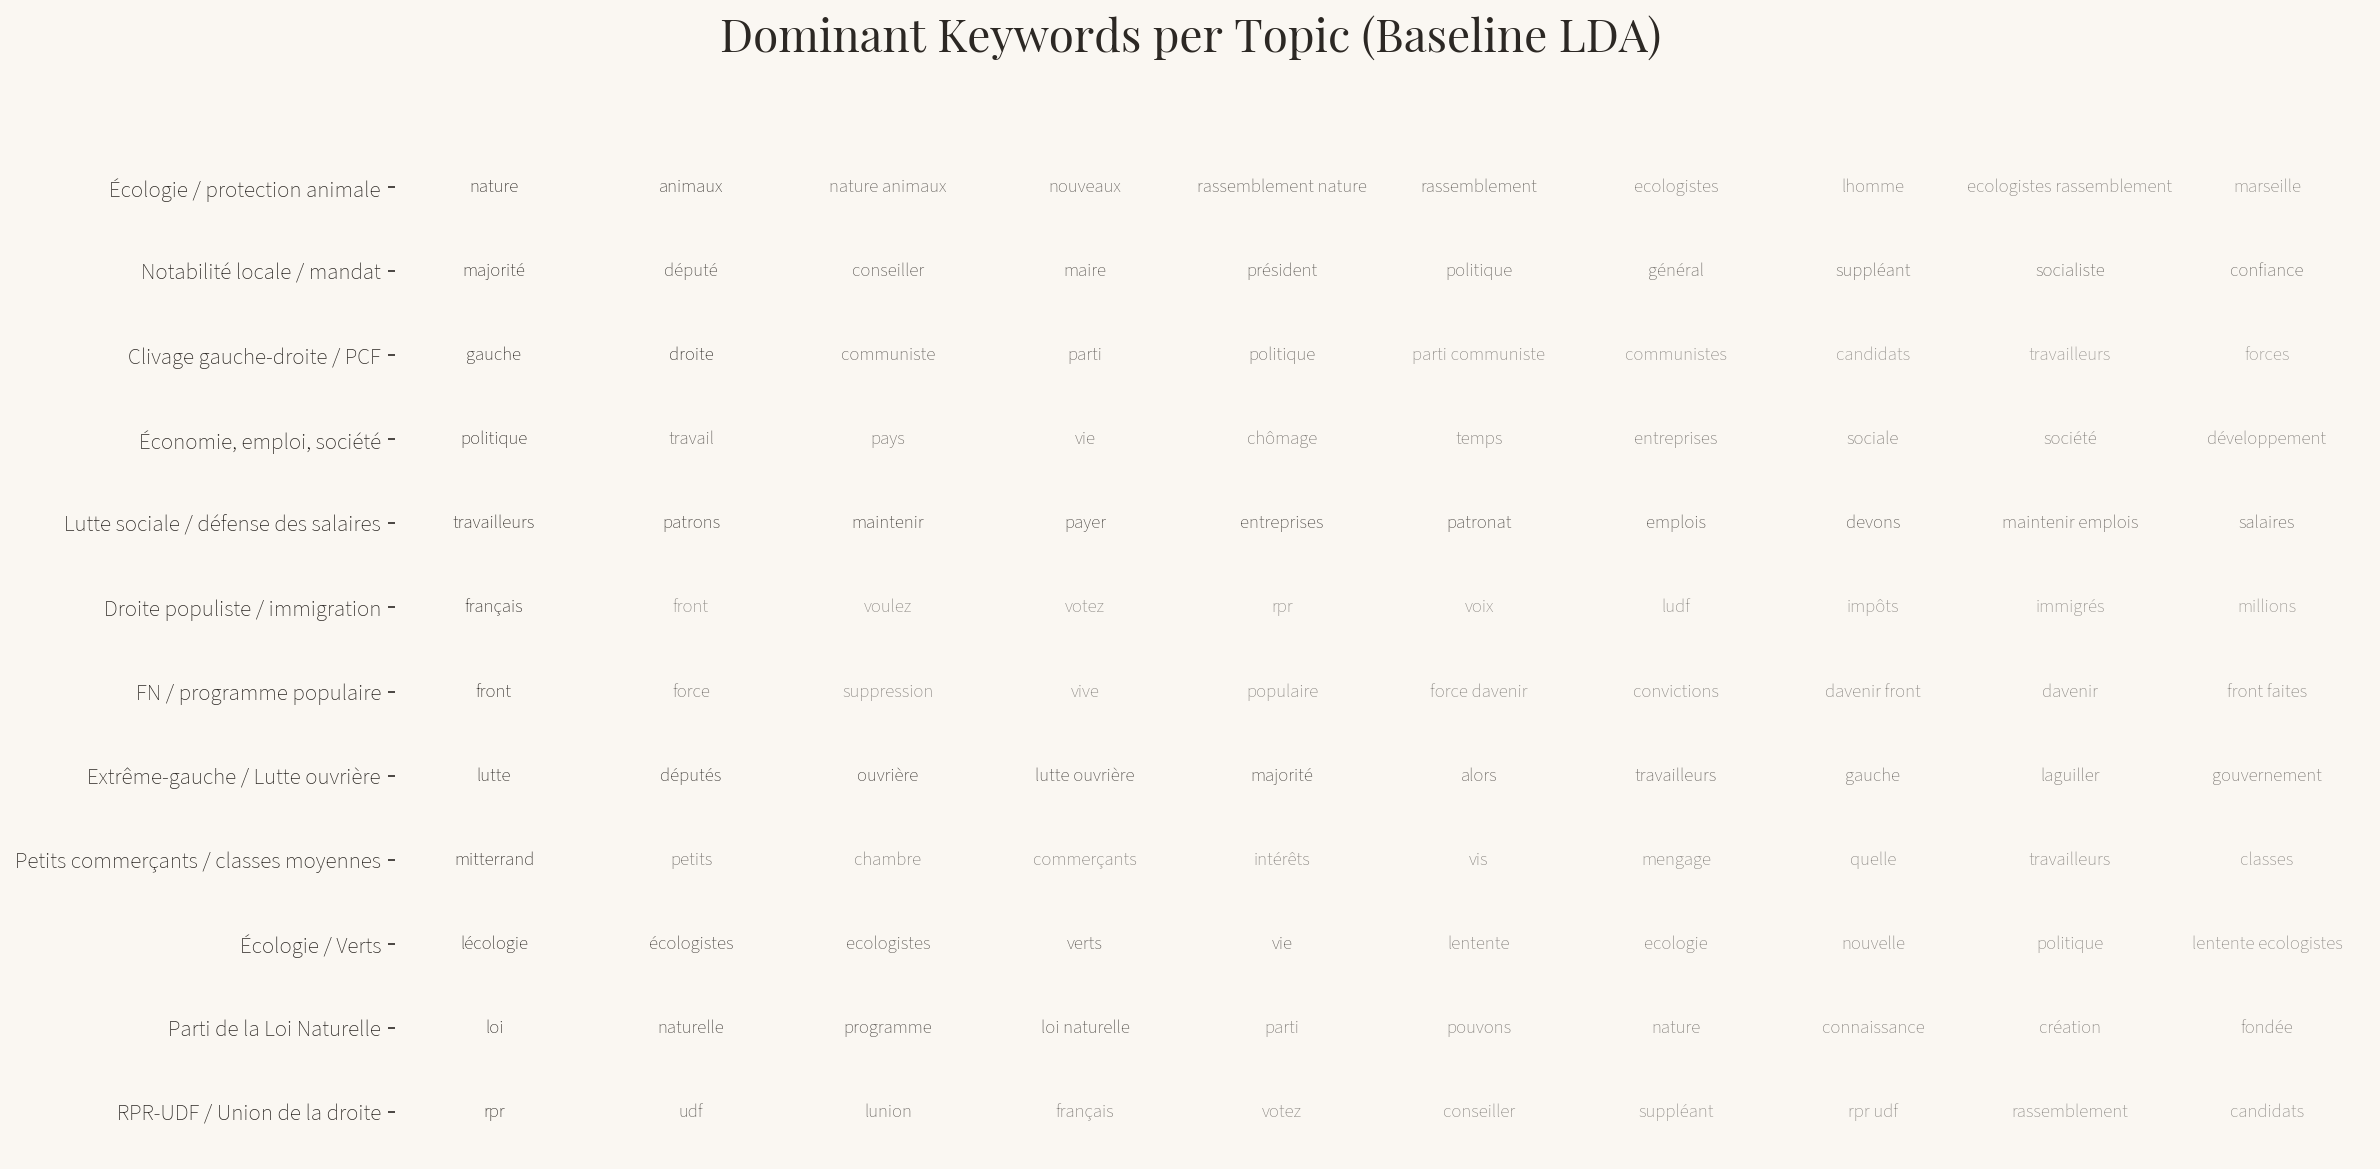

In [8]:
n_words_display = 10

fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle("Dominant Keywords per Topic (Baseline LDA)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

ax.set_xlim(0, n_words_display)
ax.set_ylim(-0.5, N_TOPICS - 0.5)
ax.invert_yaxis()

for i in range(N_TOPICS):
    weights = lda.components_[i]
    top_indices = weights.argsort()[-n_words_display:][::-1]
    max_w = weights[top_indices[0]]
    for j, word_idx in enumerate(top_indices):
        w = weights[word_idx]
        alpha = 0.3 + 0.7 * (w / max_w)
        ax.text(j + 0.5, i, feature_names[word_idx],
                ha='center', va='center', fontsize=9,
                fontfamily=FONT_BODY, fontweight='bold',
                color=TEXT_COLOR, alpha=alpha)

ax.set_yticks(range(N_TOPICS))
ax.set_yticklabels([TOPIC_NAMES.get(i, f"Topic {i}") for i in range(N_TOPICS)],
                    fontfamily=FONT_BODY, fontsize=11)
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("../data/lda_topic_words.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Observation:** The baseline LDA captures **partisan identities** rather than policy themes. Topics 0, 4, 5, 6, 7, 9, 10, 11 are essentially party-specific clusters (ecology parties, FN, Lutte ouvrière, RPR-UDF, etc.). Only Topic 3 ("Économie, emploi, société") represents a genuine cross-partisan theme. This motivates the improved approach in Part B.

### 4.2 Assign topics to documents

In [9]:
df_topic['topic_dominant'] = lda_topics.argmax(axis=1)
df_topic['topic_score'] = lda_topics.max(axis=1)

for i in range(N_TOPICS):
    df_topic[f'topic_{i}'] = lda_topics[:, i]

topic_cmap = plt.cm.Set3
topic_colors = [topic_cmap(i / N_TOPICS) for i in range(N_TOPICS)]

print("=== Dominant topic distribution ===")
print(df_topic['topic_dominant'].value_counts().sort_index())

=== Dominant topic distribution ===
topic_dominant
0      466
1     6711
2     1299
3     1701
4      236
5      581
6      522
8       57
9      461
10      97
11     288
Name: count, dtype: int64


### 4.3 Topic distribution by year

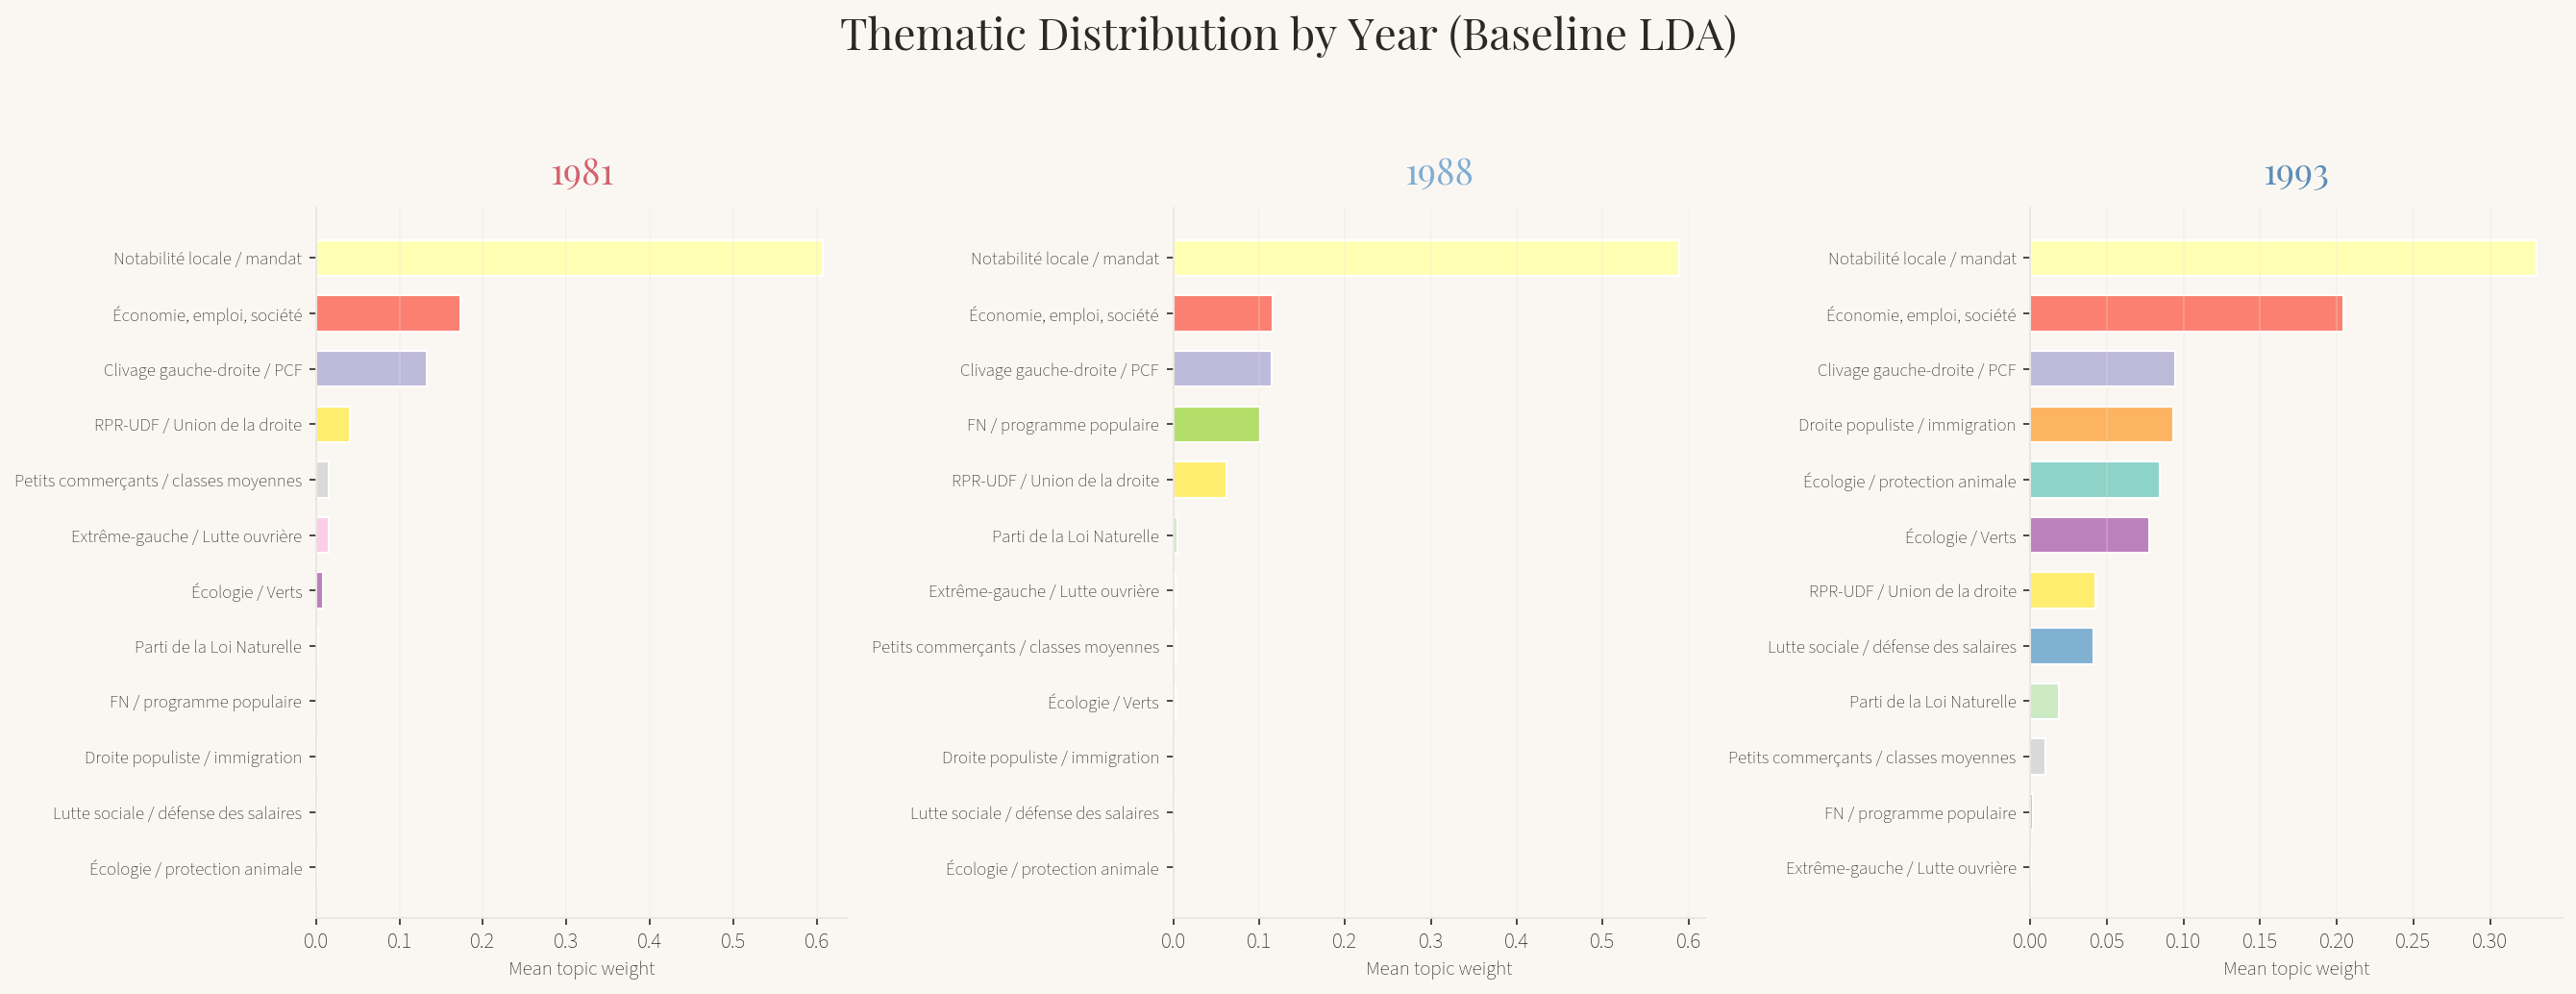

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Thematic Distribution by Year (Baseline LDA)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.98)

for idx, year in enumerate(sorted(df_topic['year'].unique())):
    ax = axes[idx]
    year_data = df_topic[df_topic['year'] == year]
    topic_means = year_data[[f'topic_{i}' for i in range(N_TOPICS)]].mean()
    topic_means = topic_means.sort_values(ascending=True)
    topics_sorted = [int(t.split('_')[1]) for t in topic_means.index]
    labels = [TOPIC_NAMES.get(t, f"Topic {t}") for t in topics_sorted]
    colors = [topic_colors[t] for t in topics_sorted]
    ax.barh(range(N_TOPICS), topic_means.values, height=0.65,
            color=colors, edgecolor='white', linewidth=1)
    ax.set_yticks(range(N_TOPICS))
    ax.set_yticklabels(labels, fontsize=9, fontfamily=FONT_BODY)
    ax.set_title(year, fontfamily=FONT_TITLE, fontsize=18, fontweight='bold',
                 color=YEAR_COLORS.get(year, TEXT_COLOR), pad=12)
    ax.set_xlabel("Mean topic weight", fontsize=10)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/topics_par_annee.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 4.4 Heatmap: topics × parties

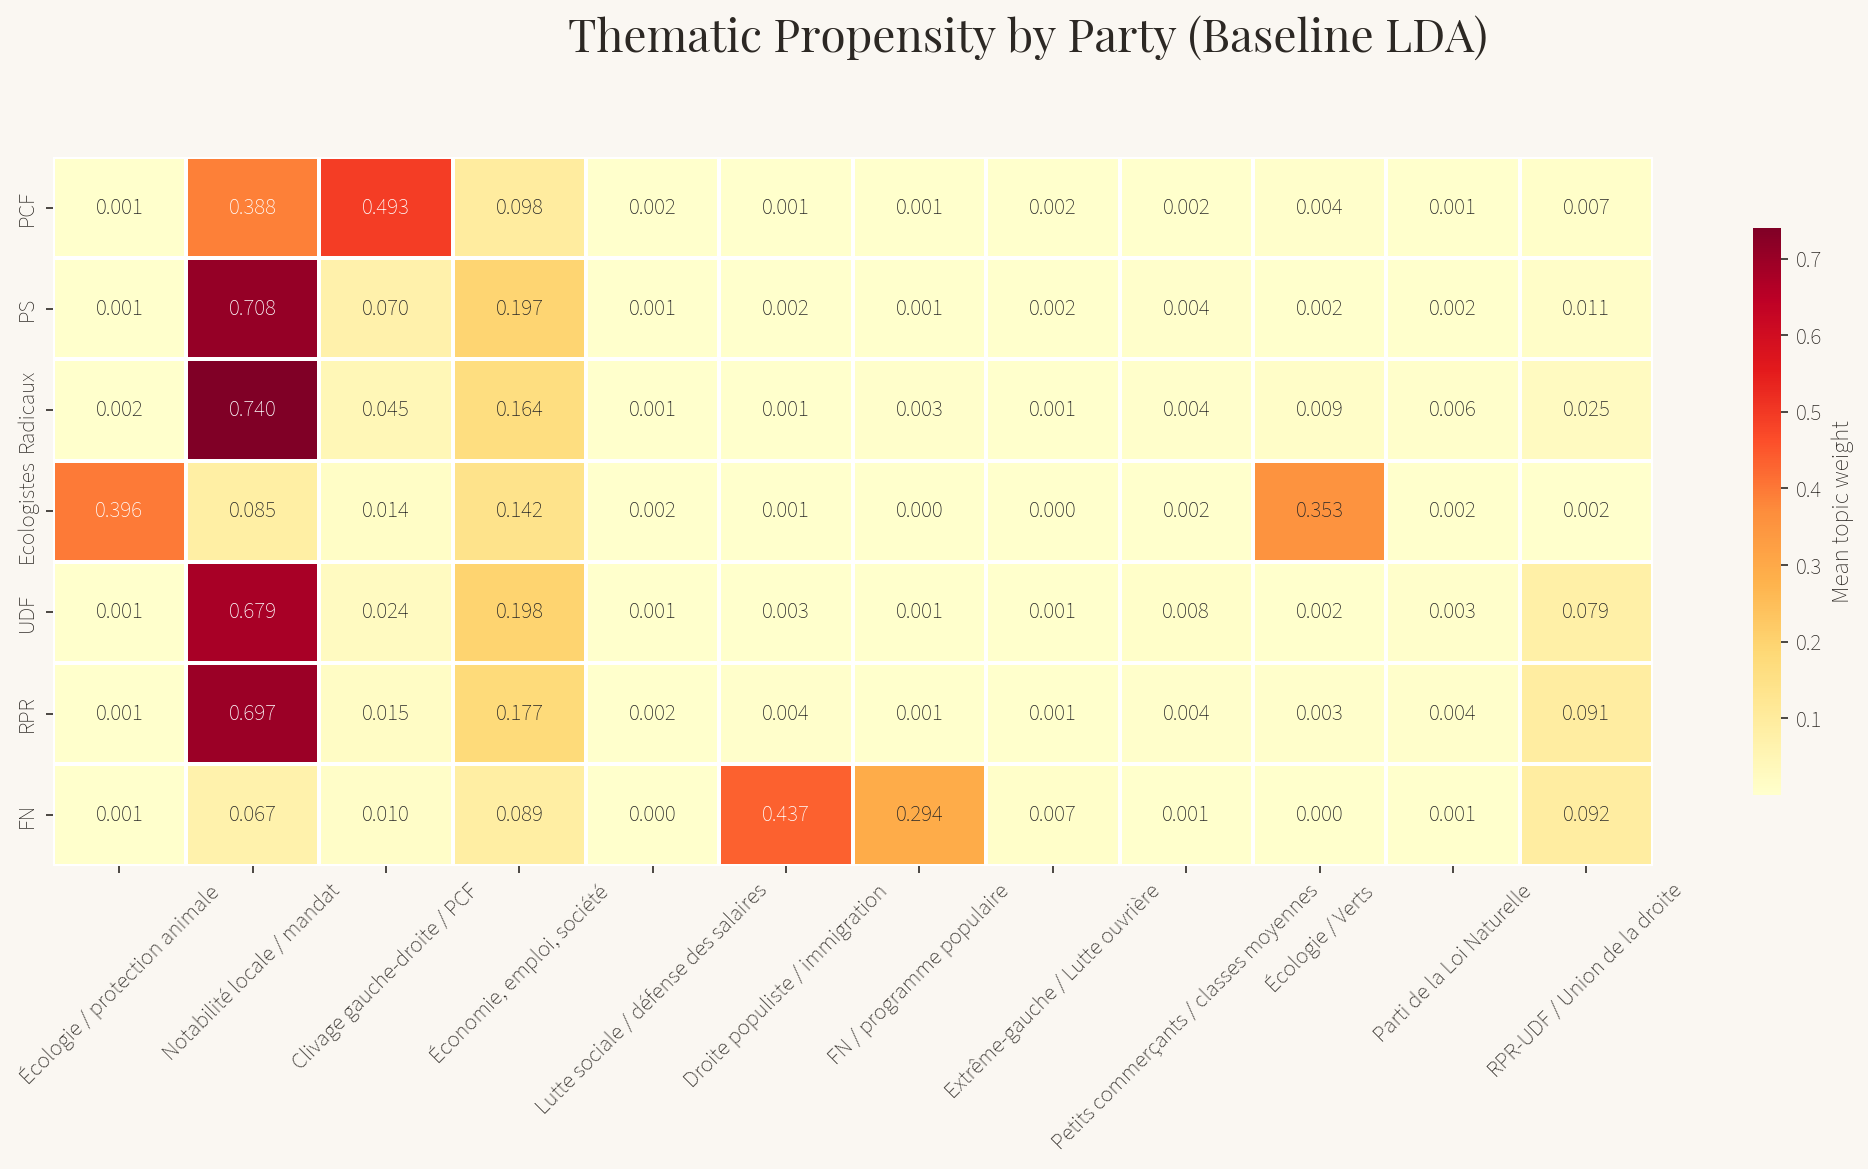

In [11]:
main_parties = ['PCF', 'PS', 'Radicaux', 'Ecologistes', 'UDF', 'RPR', 'FN']

fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Thematic Propensity by Party (Baseline LDA)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

df_main = df_topic[df_topic['parti_famille'].isin(main_parties)]
topic_party = df_main.groupby('parti_famille')[[f'topic_{i}' for i in range(N_TOPICS)]].mean()
topic_party.columns = [TOPIC_NAMES.get(i, f"Topic {i}") for i in range(N_TOPICS)]
party_order = [p for p in main_parties if p in topic_party.index]
topic_party = topic_party.loc[party_order]

sns.heatmap(topic_party, cmap='YlOrRd', annot=True, fmt='.3f',
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Mean topic weight', 'shrink': 0.8})
ax.set_ylabel(''); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/heatmap_topics_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

The heatmap confirms the problem: each topic aligns almost perfectly with one party family, demonstrating that the baseline LDA is capturing **who speaks** rather than **what is discussed**.

### 4.5 Partisan specialization (deviation from national average)

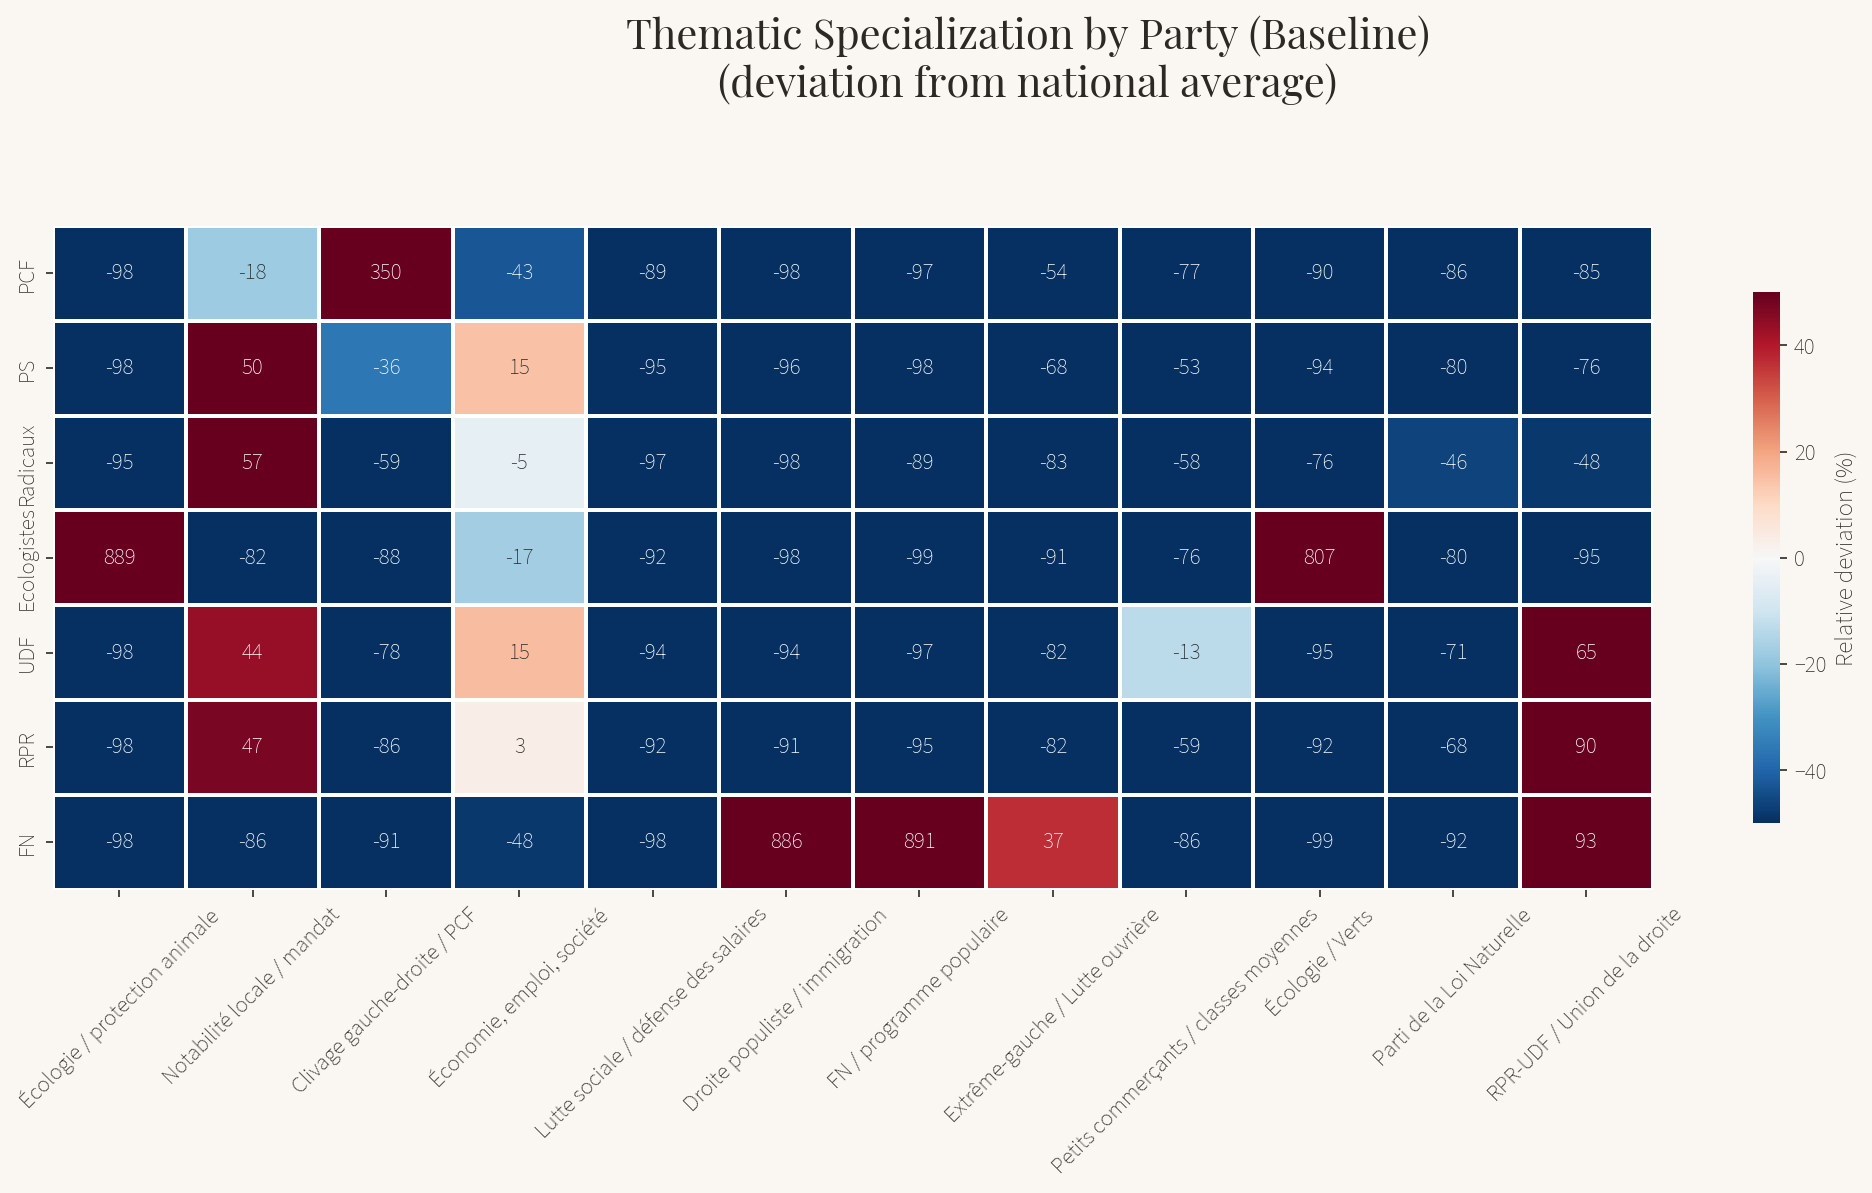

In [12]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Thematic Specialization by Party (Baseline)\n(deviation from national average)",
             fontfamily=FONT_TITLE, fontsize=20, fontweight='bold', y=0.99)

national_mean = df_topic[[f'topic_{i}' for i in range(N_TOPICS)]].mean()
specialization = topic_party.copy()
for col_idx, col in enumerate(specialization.columns):
    specialization[col] = (specialization[col] - national_mean.iloc[col_idx]) / national_mean.iloc[col_idx] * 100

sns.heatmap(specialization, cmap='RdBu_r', center=0, annot=True, fmt='.0f',
            linewidths=1, linecolor='white', ax=ax, vmin=-50, vmax=50,
            cbar_kws={'label': 'Relative deviation (%)', 'shrink': 0.8})
ax.set_ylabel(''); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/specialisation_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

---

# Part B — Improved Model (Partisan Vocabulary Removed)

## 5. Diagnosis

The baseline LDA captures **partisan identities** rather than policy themes. This is because:
1. Party names, leader names, and slogans form very distinctive vocabulary clusters
2. Each political family has ritualistic formulas ("Vive la France", "Lutte ouvrière", etc.)
3. The LDA model, being unsupervised, latches onto the most statistically distinctive word groups

**Solution:** Remove all partisan vocabulary from the feature space before training. This forces the model to find structure in the *substantive* content of the manifestos.

## 6. Extended Partisan Stopwords

In [13]:
STOPWORDS_PARTISAN = STOPWORDS_FR + [
    # Party names and abbreviations
    'front', 'rpr', 'udf', 'pcf', 'rpf', 'fnr',
    'communiste', 'communistes', 'socialiste', 'socialistes',
    'gaulliste', 'gaullistes', 'écologiste', 'écologistes',
    'ecologiste', 'ecologistes', 'verts', 'vert',
    'radical', 'radicaux', 'centriste', 'centristes',
    'lutte', 'ouvrière', 'laguiller', 'arlette',
    'mitterrand', 'chirac', 'giscard', 'marchais', 'barre', 'lepen', 'pen',
    # Electoral vocabulary
    'parti', 'partis', 'mouvement', 'rassemblement', 'union',
    'coalition', 'alliance', 'entente', 'liste',
    'député', 'députés', 'suppléant', 'suppléante',
    'conseiller', 'conseillère', 'maire', 'président',
    'sénateur', 'assemblée', 'sénat', 'parlement',
    'candidat', 'candidate', 'candidats', 'candidates',
    'mandat', 'mandats', 'élu', 'élue', 'élus',
    'votez', 'voter', 'voix', 'bulletin', 'urne',
    'confiance', 'soutien', 'soutenir', 'appel',
    'circonscription', 'arrondissement', 'canton', 'scrutin', 'ballottage',
    'madame', 'monsieur', 'mademoiselle', 'chers',
    'concitoyens', 'électeurs', 'électrices', 'mengage', 'engage', 'promets',
    # Slogans
    'vive', 'force', 'davenir', 'avenir', 'convictions', 'populaire', 'ensemble',
    'république', 'française', 'france', 'français', 'gauche', 'droite', 'centre',
    # OCR artifacts
    'lécologie', 'lentente', 'lhomme', 'lunion', 'lassemblée',
    'quil', 'quils', 'quon', 'quelles', 'cest', 'jai', 'dune', 'dun',
    'nest', 'naura', 'suis', 'jusquà', 'lorsque', 'puisque',
    # Loi Naturelle micro-party
    'naturelle', 'loi naturelle', 'connaissance', 'transcendantale', 'méditation',
]
print(f"Partisan stopwords: {len(STOPWORDS_PARTISAN)} terms")

Partisan stopwords: 301 terms


---

## 7. Optimal Number of Topics (Grid Search)

As emphasized in the course (*Chapter VI — Topic Modeling: Evaluation*), the number of topics $k$ is a crucial hyperparameter. Too few topics produce vague, overly broad themes; too many create redundant, overly specific ones.

We evaluate models with $k \in \{5, 7, 8, 10, 12, 15, 20\}$ using two metrics:
- **Perplexity** (lower = better): measures how well the model predicts held-out data
- **Log-likelihood** (higher = better): measures fit to the training data

### 7.1 Vectorization (clean)

In [14]:
count_vec_clean = CountVectorizer(
    max_features=3000, min_df=15, max_df=0.6,
    stop_words=STOPWORDS_PARTISAN, ngram_range=(1, 2),
)
count_matrix_clean = count_vec_clean.fit_transform(df_topic['text_clean'])
feature_names_clean = count_vec_clean.get_feature_names_out()
print(f"Clean document-term matrix: {count_matrix_clean.shape}")

Clean document-term matrix: (12419, 3000)


### 7.2 Grid search over number of topics

In [15]:
range_topics = [5, 7, 8, 10, 12, 15, 20]
perplexities_clean = []
log_likelihoods_clean = []

print("Testing different numbers of topics (clean vocabulary)...\n")
for n in range_topics:
    lda_test = LatentDirichletAllocation(
        n_components=n, max_iter=30, learning_method='online',
        learning_decay=0.7, random_state=42, n_jobs=-1,
        doc_topic_prior=0.1, topic_word_prior=0.01,
    )
    lda_test.fit(count_matrix_clean)
    perp = lda_test.perplexity(count_matrix_clean)
    ll = lda_test.score(count_matrix_clean)
    perplexities_clean.append(perp)
    log_likelihoods_clean.append(ll)
    print(f"  k={n:2d}  |  Perplexity: {perp:,.1f}  |  Log-likelihood: {ll:,.1f}")

Testing different numbers of topics (clean vocabulary)...

  k= 5  |  Perplexity: 8,651.4  |  Log-likelihood: -23,224,554.8
  k= 7  |  Perplexity: 7,645.9  |  Log-likelihood: -22,908,026.4
  k= 8  |  Perplexity: 7,486.3  |  Log-likelihood: -22,853,980.7
  k=10  |  Perplexity: 7,224.3  |  Log-likelihood: -22,762,721.5
  k=12  |  Perplexity: 7,191.6  |  Log-likelihood: -22,751,094.8
  k=15  |  Perplexity: 6,925.4  |  Log-likelihood: -22,654,494.6
  k=20  |  Perplexity: 6,755.7  |  Log-likelihood: -22,590,922.1


### 7.3 Visualization: optimal k selection

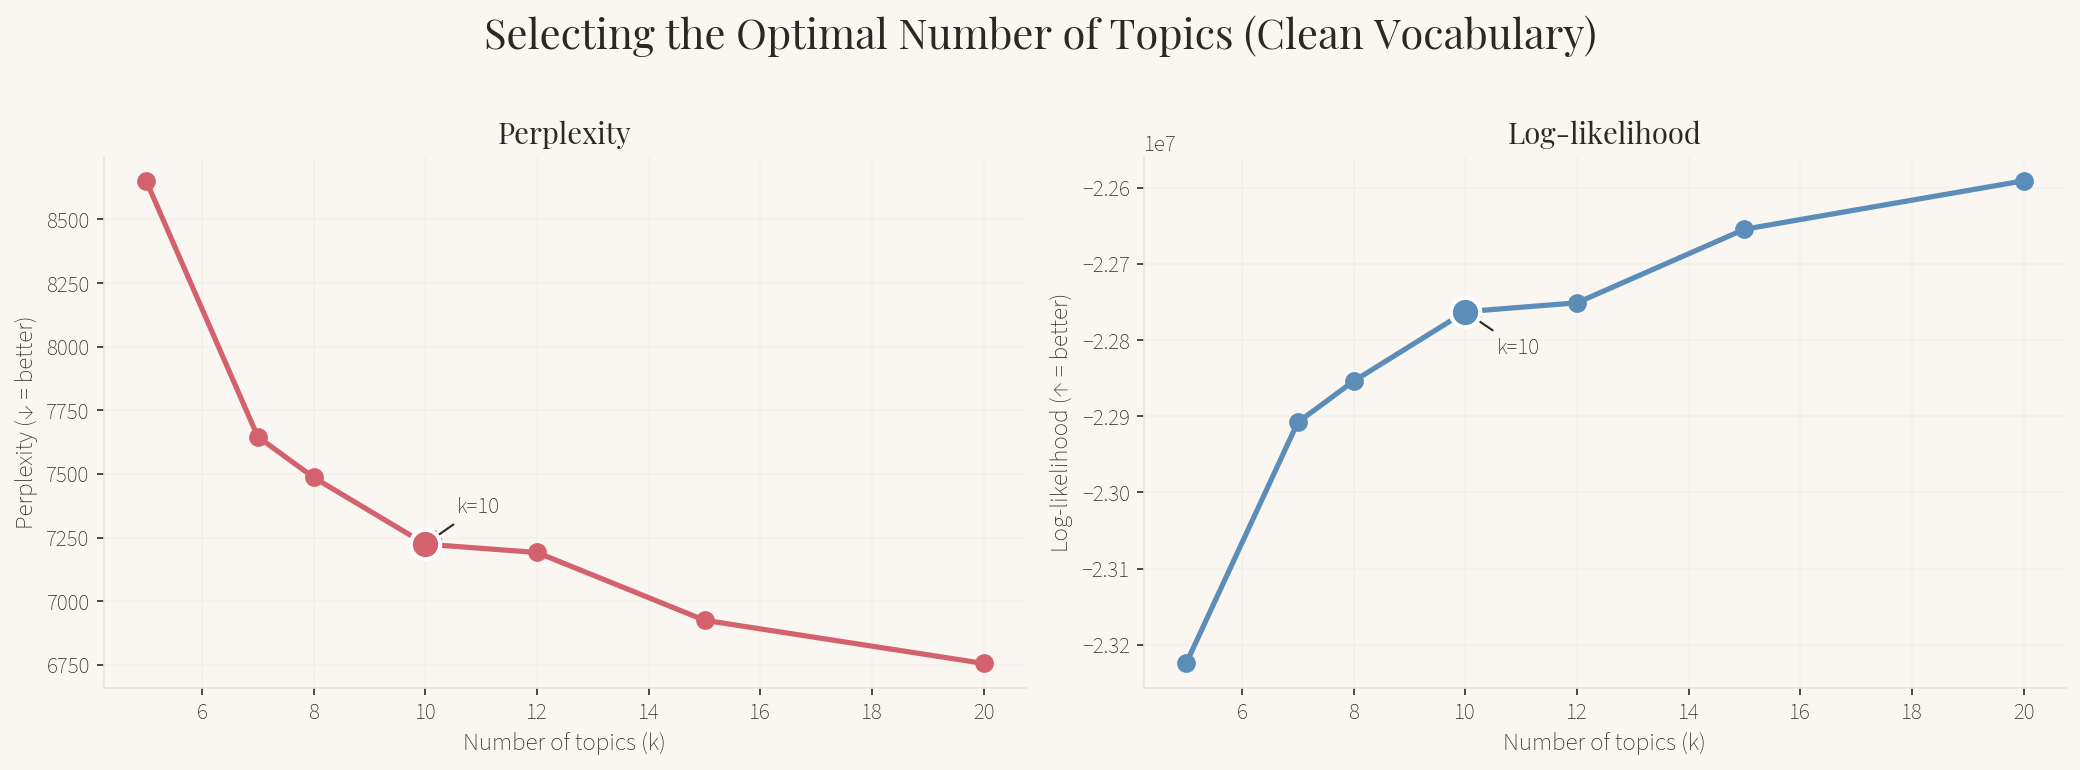

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Selecting the Optimal Number of Topics (Clean Vocabulary)",
             fontfamily=FONT_TITLE, fontsize=20, fontweight='bold', y=1.02)

ax1.plot(range_topics, perplexities_clean, 'o-', color='#D4626E', linewidth=2.5, markersize=8)
ax1.set_xlabel("Number of topics (k)")
ax1.set_ylabel("Perplexity (↓ = better)")
ax1.set_title("Perplexity", fontfamily=FONT_TITLE, fontsize=14)
ax1.grid(alpha=0.3)

# Mark the elbow / chosen k
best_idx = 3  # index of k=10 in range_topics — adjust after inspection
ax1.scatter([range_topics[best_idx]], [perplexities_clean[best_idx]],
            s=200, color='#D4626E', zorder=5, edgecolors='white', linewidth=2)
ax1.annotate(f'k={range_topics[best_idx]}', xy=(range_topics[best_idx], perplexities_clean[best_idx]),
             xytext=(15, 15), textcoords='offset points', fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=TEXT_COLOR))

ax2.plot(range_topics, log_likelihoods_clean, 'o-', color='#5B8DB8', linewidth=2.5, markersize=8)
ax2.set_xlabel("Number of topics (k)")
ax2.set_ylabel("Log-likelihood (↑ = better)")
ax2.set_title("Log-likelihood", fontfamily=FONT_TITLE, fontsize=14)
ax2.grid(alpha=0.3)

ax2.scatter([range_topics[best_idx]], [log_likelihoods_clean[best_idx]],
            s=200, color='#5B8DB8', zorder=5, edgecolors='white', linewidth=2)
ax2.annotate(f'k={range_topics[best_idx]}', xy=(range_topics[best_idx], log_likelihoods_clean[best_idx]),
             xytext=(15, -20), textcoords='offset points', fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=TEXT_COLOR))

plt.tight_layout()
plt.savefig("../data/optimal_k_clean.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Interpretation:** Perplexity decreases steadily as $k$ increases (more topics = better fit), but the marginal improvement flattens around $k = 10$. Beyond that point, adding topics yields diminishing returns and increases the risk of redundant or uninterpretable themes. We select **$k = 10$** as the optimal number of topics for the improved model.

---

## 8. Improved LDA (k=10, Clean Vocabulary)

### 8.1 Train the improved LDA

In [17]:
N_TOPICS_CLEAN = 10

lda_clean = LatentDirichletAllocation(
    n_components=N_TOPICS_CLEAN, max_iter=50,
    learning_method='online', learning_decay=0.7,
    random_state=42, n_jobs=-1,
    doc_topic_prior=0.1, topic_word_prior=0.01,
)
lda_clean_topics = lda_clean.fit_transform(count_matrix_clean)

print(f"Improved LDA trained: {N_TOPICS_CLEAN} topics")
print(f"Perplexity: {lda_clean.perplexity(count_matrix_clean):.1f}")

print("\n=== Improved LDA Topics ===\n")
topic_words_clean = get_topic_words(lda_clean, feature_names_clean, n_words=12)
for topic_id, words in topic_words_clean.items():
    print(f"Topic {topic_id:2d} : {', '.join(words)}")

Improved LDA trained: 10 topics
Perplexity: 7214.9

=== Improved LDA Topics ===

Topic  0 : travailleurs, majorité, gouvernement, alors, hommes, quelle, petits, opposer, intérêts, faveur, possible, fidèle
Topic  1 : suppression, ludf, faites, peine, famille, mort, peine mort, taxe, immigrés, drogue, mères, limmigration
Topic  2 : vie, société, temps, chômage, programme, monde, pays, travail, loi, citoyens, démocratie, nouvelle
Topic  3 : sociale, formation, développement, pays, solidarité, entreprises, sécurité, vie, jeunes, travail, personnes, économique
Topic  4 : nature, animaux, nature animaux, nouveaux, nouveaux nature, marseille, fonds cevipov, cevipov, écarté, adresse, postal, pratiquée
Topic  5 : travailleurs, patrons, maintenir, payer, entreprises, patronat, emplois, devons, chômage, salaires, maintenir emplois, bourgeoisie
Topic  6 : vie, nouvelle, generation, chance, génération, lenvironnement, ecologie, génération ecologie, rendue possible, remplisse, choisissez seule, soci

### 8.2 Improved NMF (for comparison)

NMF (Non-negative Matrix Factorization) works on TF-IDF matrices and tends to produce sparser, more interpretable topics. We train it alongside LDA for comparison.

In [18]:
tfidf_vec_clean = TfidfVectorizer(
    max_features=3000, min_df=15, max_df=0.6,
    stop_words=STOPWORDS_PARTISAN, ngram_range=(1, 2),
)
tfidf_matrix_clean = tfidf_vec_clean.fit_transform(df_topic['text_clean'])
tfidf_features_clean = tfidf_vec_clean.get_feature_names_out()

nmf_clean = NMF(n_components=N_TOPICS_CLEAN, random_state=42,
                max_iter=500, init='nndsvda')
nmf_clean_topics = nmf_clean.fit_transform(tfidf_matrix_clean)

print("=== Improved NMF Topics ===\n")
nmf_topic_words_clean = get_topic_words(nmf_clean, tfidf_features_clean, n_words=12)
for topic_id, words in nmf_topic_words_clean.items():
    print(f"Topic {topic_id:2d} : {', '.join(words)}")

=== Improved NMF Topics ===

Topic  0 : vie, pays, travail, sociale, développement, lemploi, société, formation, chômage, loi, temps, monde
Topic  1 : jusquici, suppression, faites, ludf, fois sentendra, travaille créer, antisocialistes préférence, sentendra, défende liberté, effectivement lequel, préférence priorité, dinitiative fidèle
Topic  2 : animaux, nature, nature animaux, nouveaux nature, nouveaux, marseille, ruffi marseille, rue ruffi, abandons mauvais, ruffi, fondamentales lêtre, internationales veiller
Topic  3 : supprimant, carte, voulez, impôts, sauver, ludf, immigrés, bas, millions, limmigration, vont, nationalité
Topic  4 : generation, chance, génération, ecologie, génération ecologie, vie, planète, réconcilier, lenvironnement, réconcilier léconomie, lecologie, léconomie nature
Topic  5 : patrons, payer, maintenir, patronat, travailleurs, maintenir emplois, devons, bénéfices, vendre, sacrifices, comptes, bourgeoisie
Topic  6 : travailleurs, petits, chambre, côté, préside

### 8.3 Topic naming (improved model)

In [19]:
TOPIC_NAMES_CLEAN = {
    0: "Rhétorique travailliste / petits commerçants",
    1: "Programme sécuritaire / peine de mort",
    2: "Société, démocratie, citoyenneté",
    3: "Politique sociale et économique",
    4: "Protection animale (micro-parti)",
    5: "Lutte des classes / extrême-gauche",
    6: "Génération Écologie / environnement",
    7: "Revendications salariales / monde du travail",
    8: "Immigration et fiscalité (FN)",
    9: "Alternance politique / victoire électorale",
}

# Select the best model (LDA clean)
best_topics = lda_clean_topics
best_n_topics = N_TOPICS_CLEAN
best_model = lda_clean
best_features = feature_names_clean

# Assign to DataFrame
df_topic['topic_dominant_v2'] = best_topics.argmax(axis=1)
df_topic['topic_score_v2'] = best_topics.max(axis=1)
topic_cols_v2 = []
for i in range(best_n_topics):
    col = f'topic_v2_{i}'
    df_topic[col] = best_topics[:, i]
    topic_cols_v2.append(col)

print("Distribution of improved topics:")
for t in range(best_n_topics):
    count = (df_topic['topic_dominant_v2'] == t).sum()
    name = TOPIC_NAMES_CLEAN.get(t, f"Topic {t}")
    print(f"  {t:2d}. {name:45s} : {count:5d} ({count/len(df_topic)*100:.1f}%)")

Distribution of improved topics:
   0. Rhétorique travailliste / petits commerçants  :   261 (2.1%)
   1. Programme sécuritaire / peine de mort         :   523 (4.2%)
   2. Société, démocratie, citoyenneté              :  1443 (11.6%)
   3. Politique sociale et économique               :  2812 (22.6%)
   4. Protection animale (micro-parti)              :   532 (4.3%)
   5. Lutte des classes / extrême-gauche            :   235 (1.9%)
   6. Génération Écologie / environnement           :   407 (3.3%)
   7. Revendications salariales / monde du travail  :   882 (7.1%)
   8. Immigration et fiscalité (FN)                 :   584 (4.7%)
   9. Alternance politique / victoire électorale    :  4740 (38.2%)


---

## 9. Improved Visualizations

### 9.1 Three-model comparison

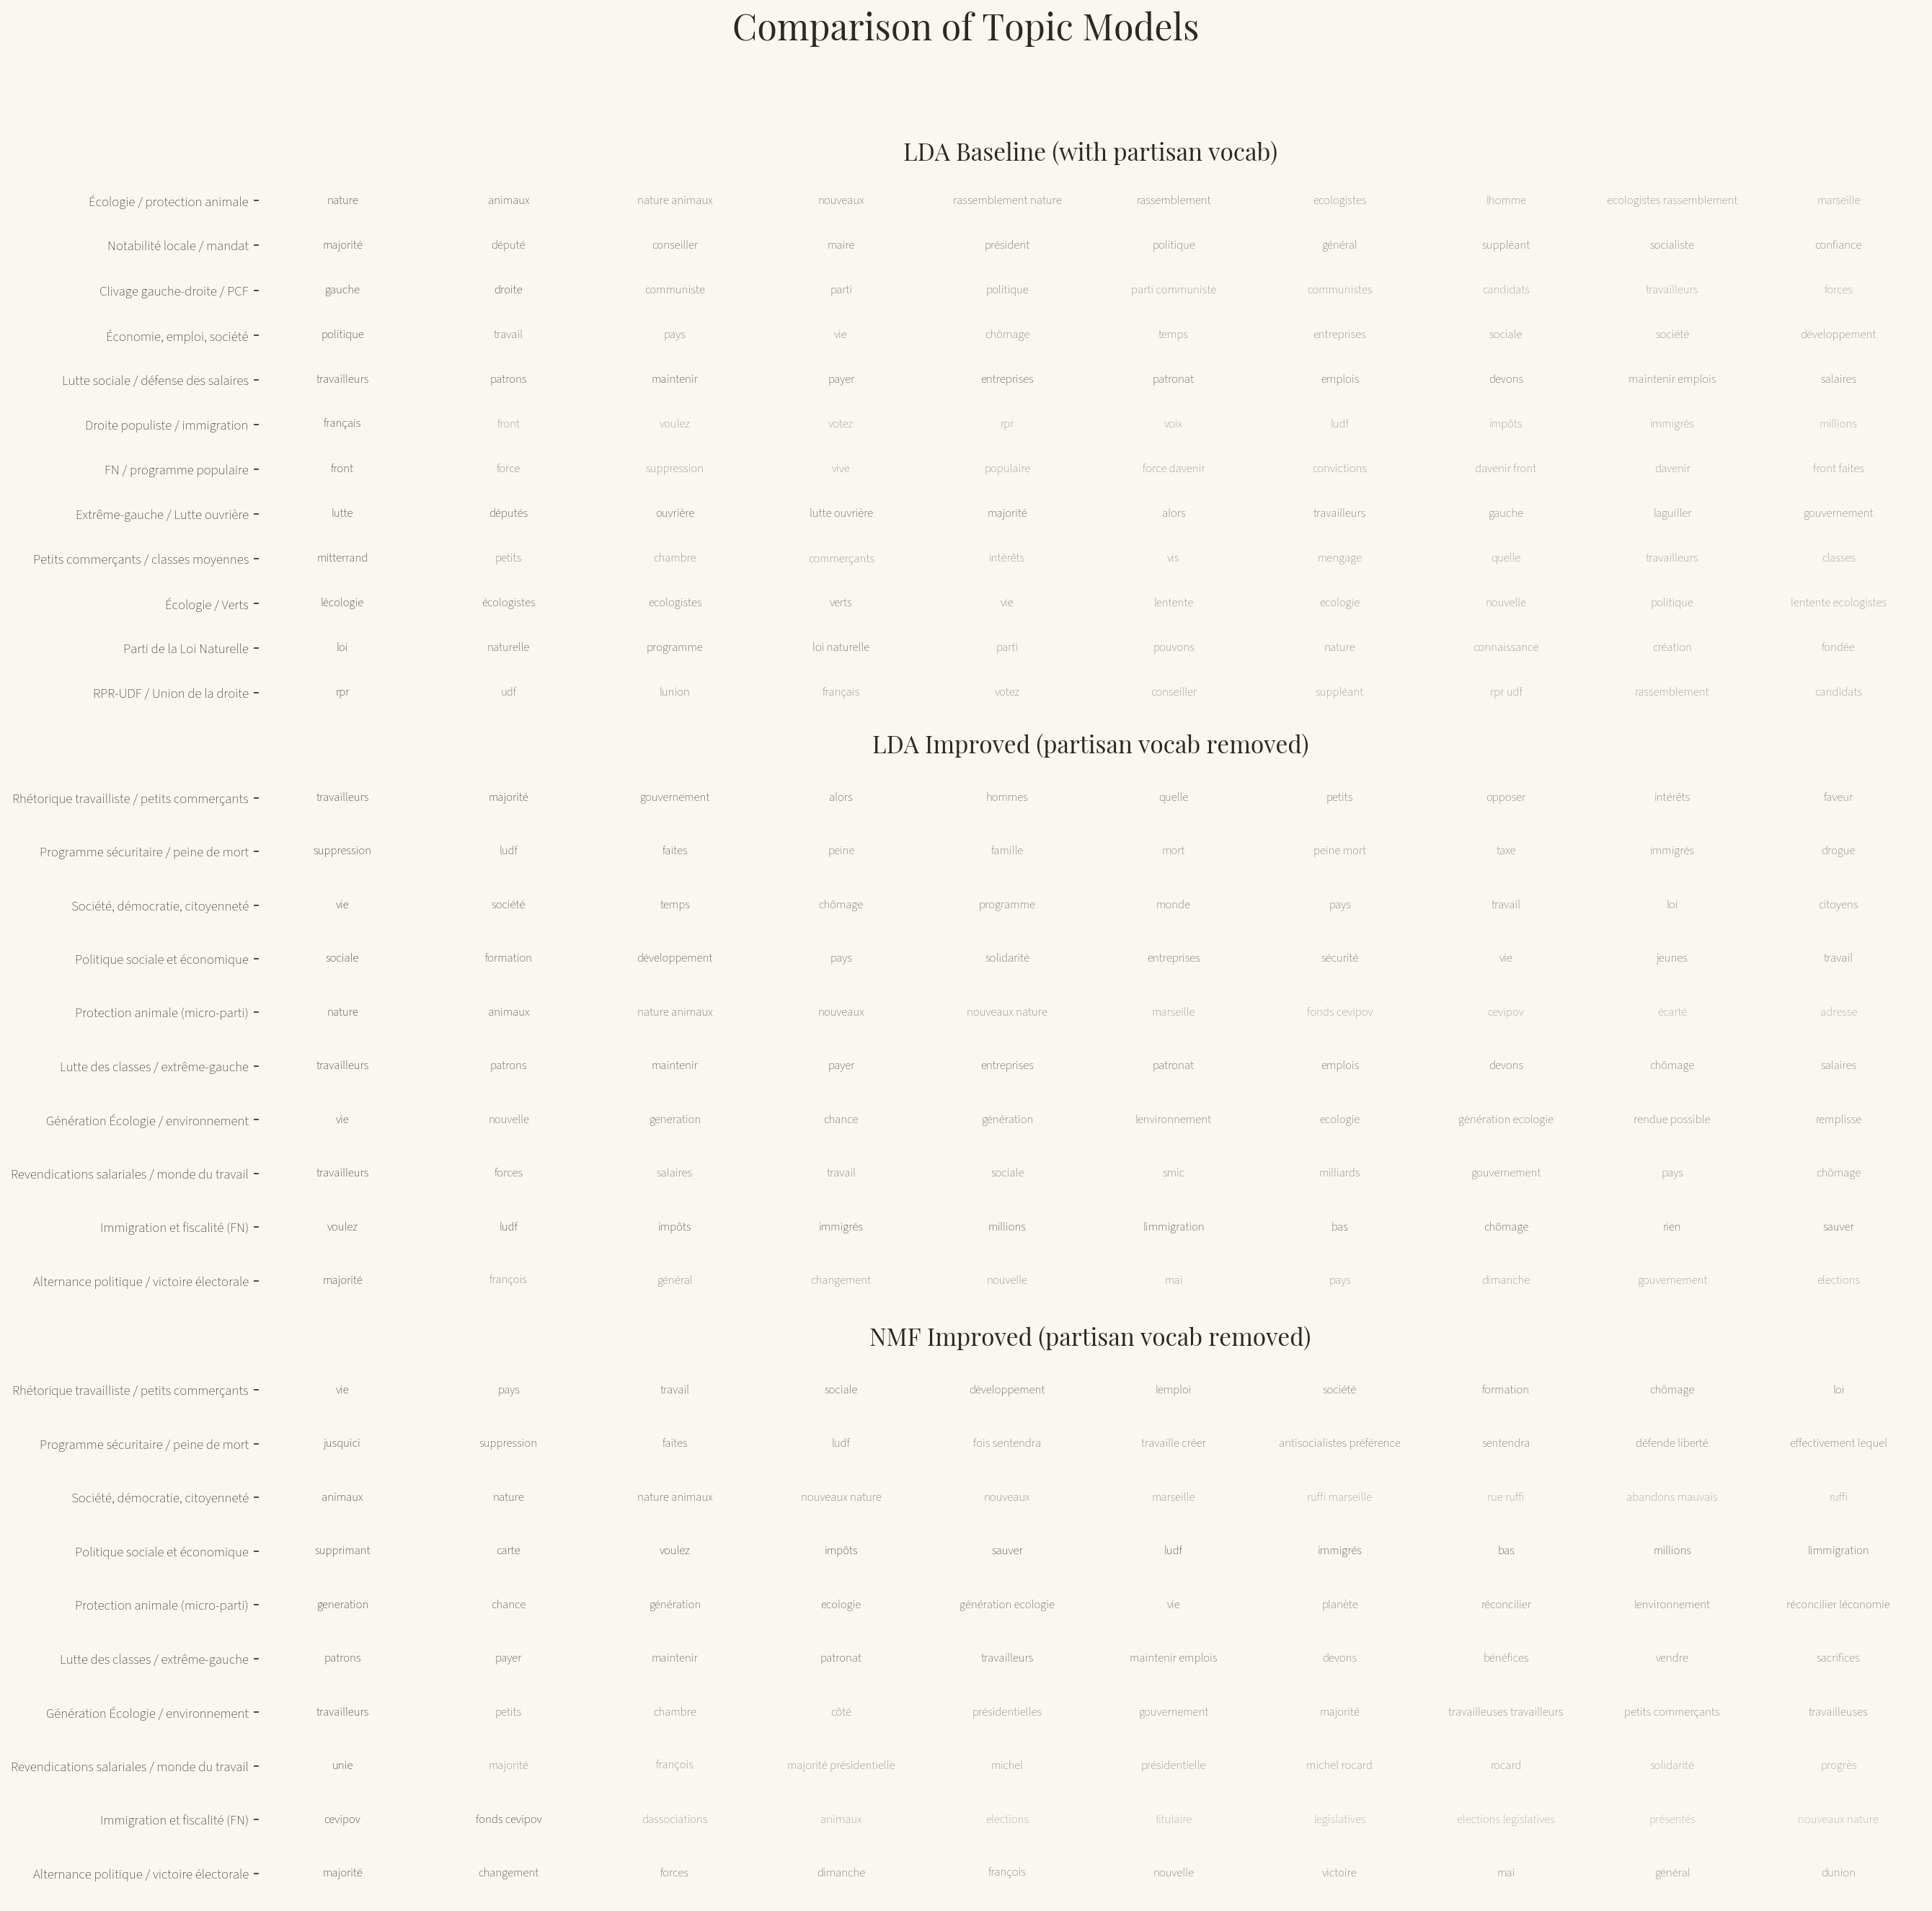

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(18, 18))
fig.suptitle("Comparison of Topic Models",
             fontfamily=FONT_TITLE, fontsize=24, fontweight='bold', y=0.98)

n_words_display = 10
configs = [
    ("LDA Baseline (with partisan vocab)", lda, feature_names, N_TOPICS, TOPIC_NAMES),
    ("LDA Improved (partisan vocab removed)", lda_clean, feature_names_clean, N_TOPICS_CLEAN, TOPIC_NAMES_CLEAN),
    ("NMF Improved (partisan vocab removed)", nmf_clean, tfidf_features_clean, N_TOPICS_CLEAN, TOPIC_NAMES_CLEAN),
]

for model_idx, (title, model_obj, features, n_top, names) in enumerate(configs):
    ax = axes[model_idx]
    ax.set_xlim(0, n_words_display)
    ax.set_ylim(-0.5, n_top - 0.5)
    ax.invert_yaxis()
    for i in range(n_top):
        weights = model_obj.components_[i]
        top_indices = weights.argsort()[-n_words_display:][::-1]
        max_w = weights[top_indices[0]]
        for j, word_idx in enumerate(top_indices):
            w = weights[word_idx]
            alpha_val = max(0.0, min(1.0, 0.3 + 0.7 * (w / max_w) if max_w > 0 else 0.3))
            ax.text(j + 0.5, i, features[word_idx],
                    ha='center', va='center', fontsize=8,
                    fontfamily=FONT_BODY, fontweight='bold',
                    color=TEXT_COLOR, alpha=alpha_val)
    ax.set_yticks(range(n_top))
    ax.set_yticklabels([names.get(i, f"Topic {i}") for i in range(n_top)], fontsize=9)
    ax.set_xticks([])
    ax.set_title(title, fontfamily=FONT_TITLE, fontsize=16, fontweight='bold', pad=12)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../data/comparaison_3_modeles.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Reading guide:** Each row is a topic; words are ranked by importance (higher opacity = higher weight). The baseline LDA (top) captures partisan identities. The improved LDA (middle), stripped of partisan vocabulary, reveals genuine policy themes. The NMF (bottom) offers an alternative decomposition for comparison.

### 9.2 Improved heatmap: topics × parties

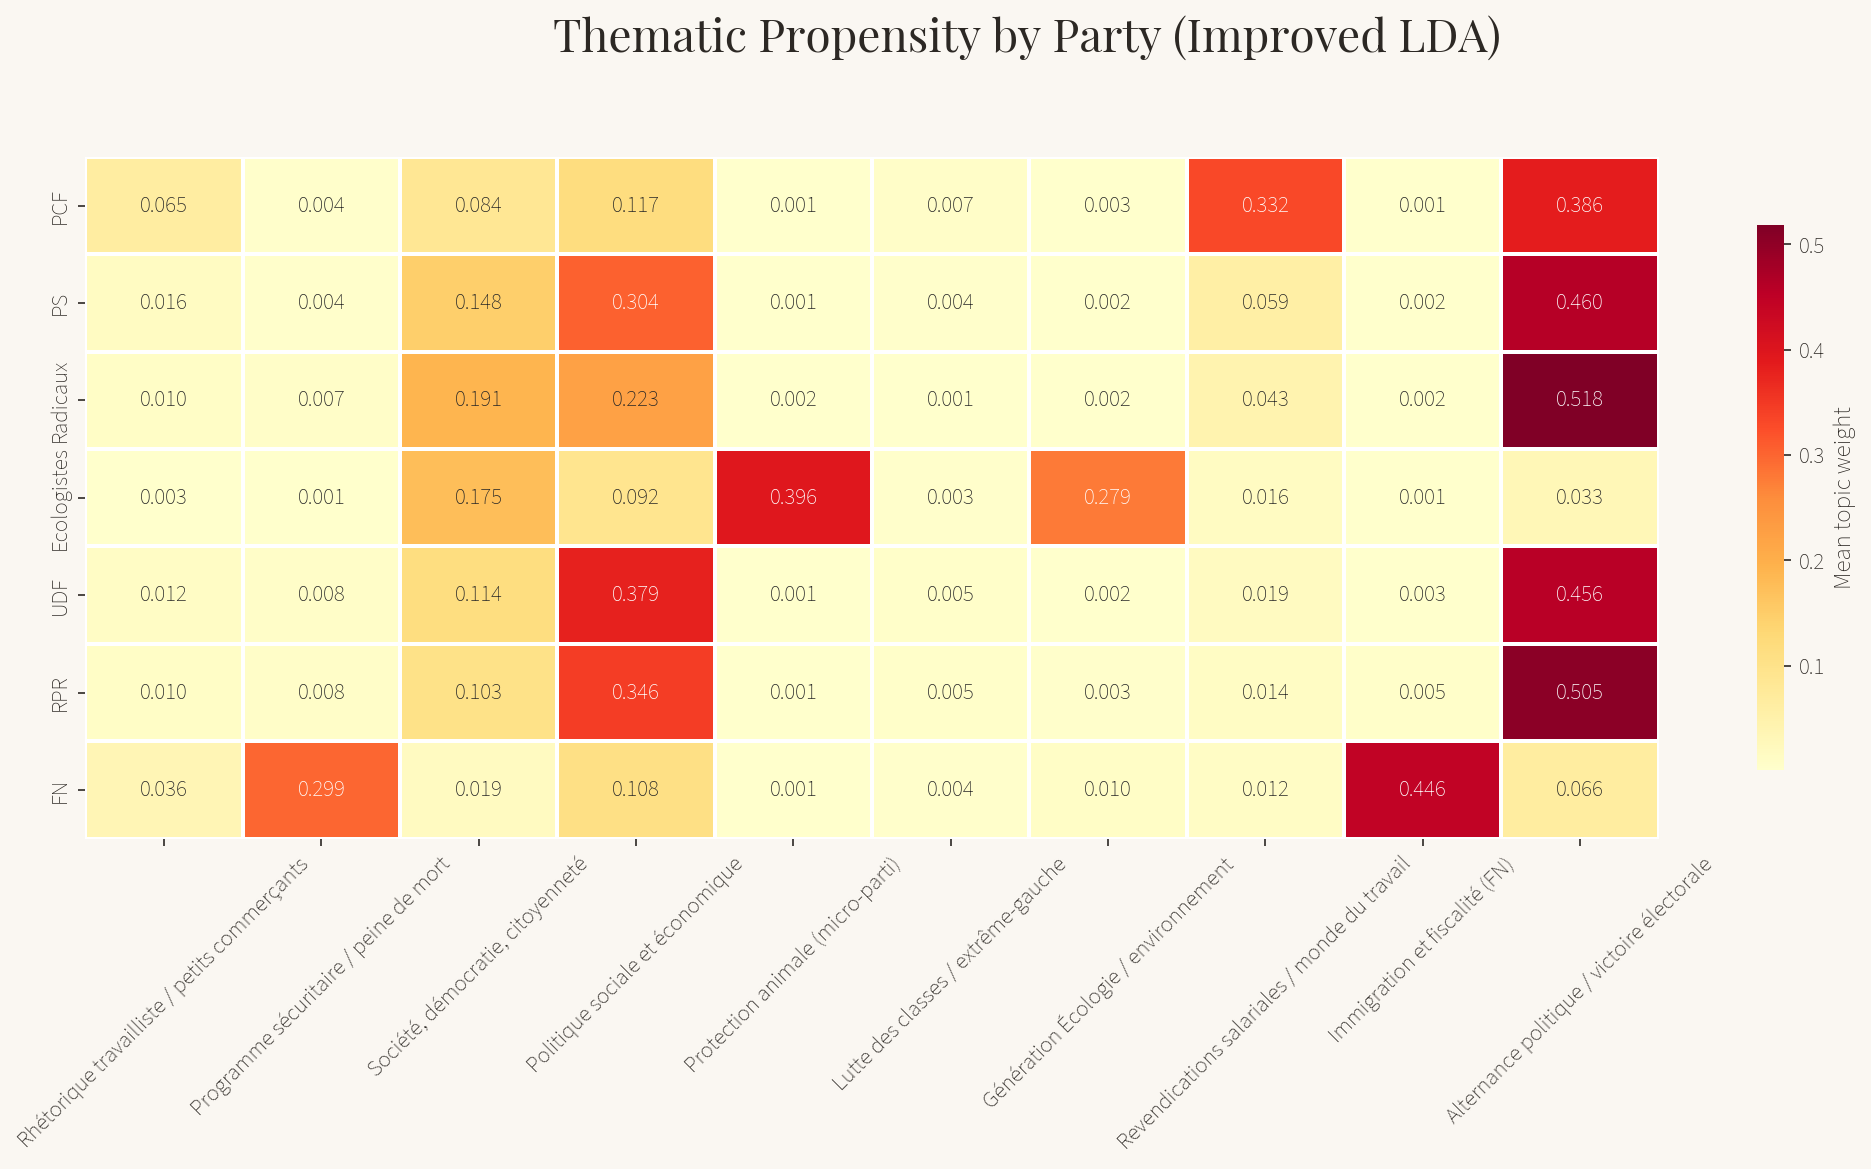

In [21]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Thematic Propensity by Party (Improved LDA)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

df_main = df_topic[df_topic['parti_famille'].isin(main_parties)]
topic_party_v2 = df_main.groupby('parti_famille')[topic_cols_v2].mean()
topic_party_v2.columns = [TOPIC_NAMES_CLEAN.get(i, f"Topic {i}") for i in range(best_n_topics)]
party_order = [p for p in main_parties if p in topic_party_v2.index]
topic_party_v2 = topic_party_v2.loc[party_order]

sns.heatmap(topic_party_v2, cmap='YlOrRd', annot=True, fmt='.3f',
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Mean topic weight', 'shrink': 0.8})
ax.set_ylabel(''); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/heatmap_topics_v2.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Reading guide:** Darker cells indicate stronger thematic focus. Parties are ordered left-to-right on the political spectrum. This heatmap should now show *cross-partisan* patterns (e.g., both PS and RPR discussing "Politique sociale et économique") rather than the one-party-one-topic pattern of the baseline.

### 9.3 Partisan specialization (improved)

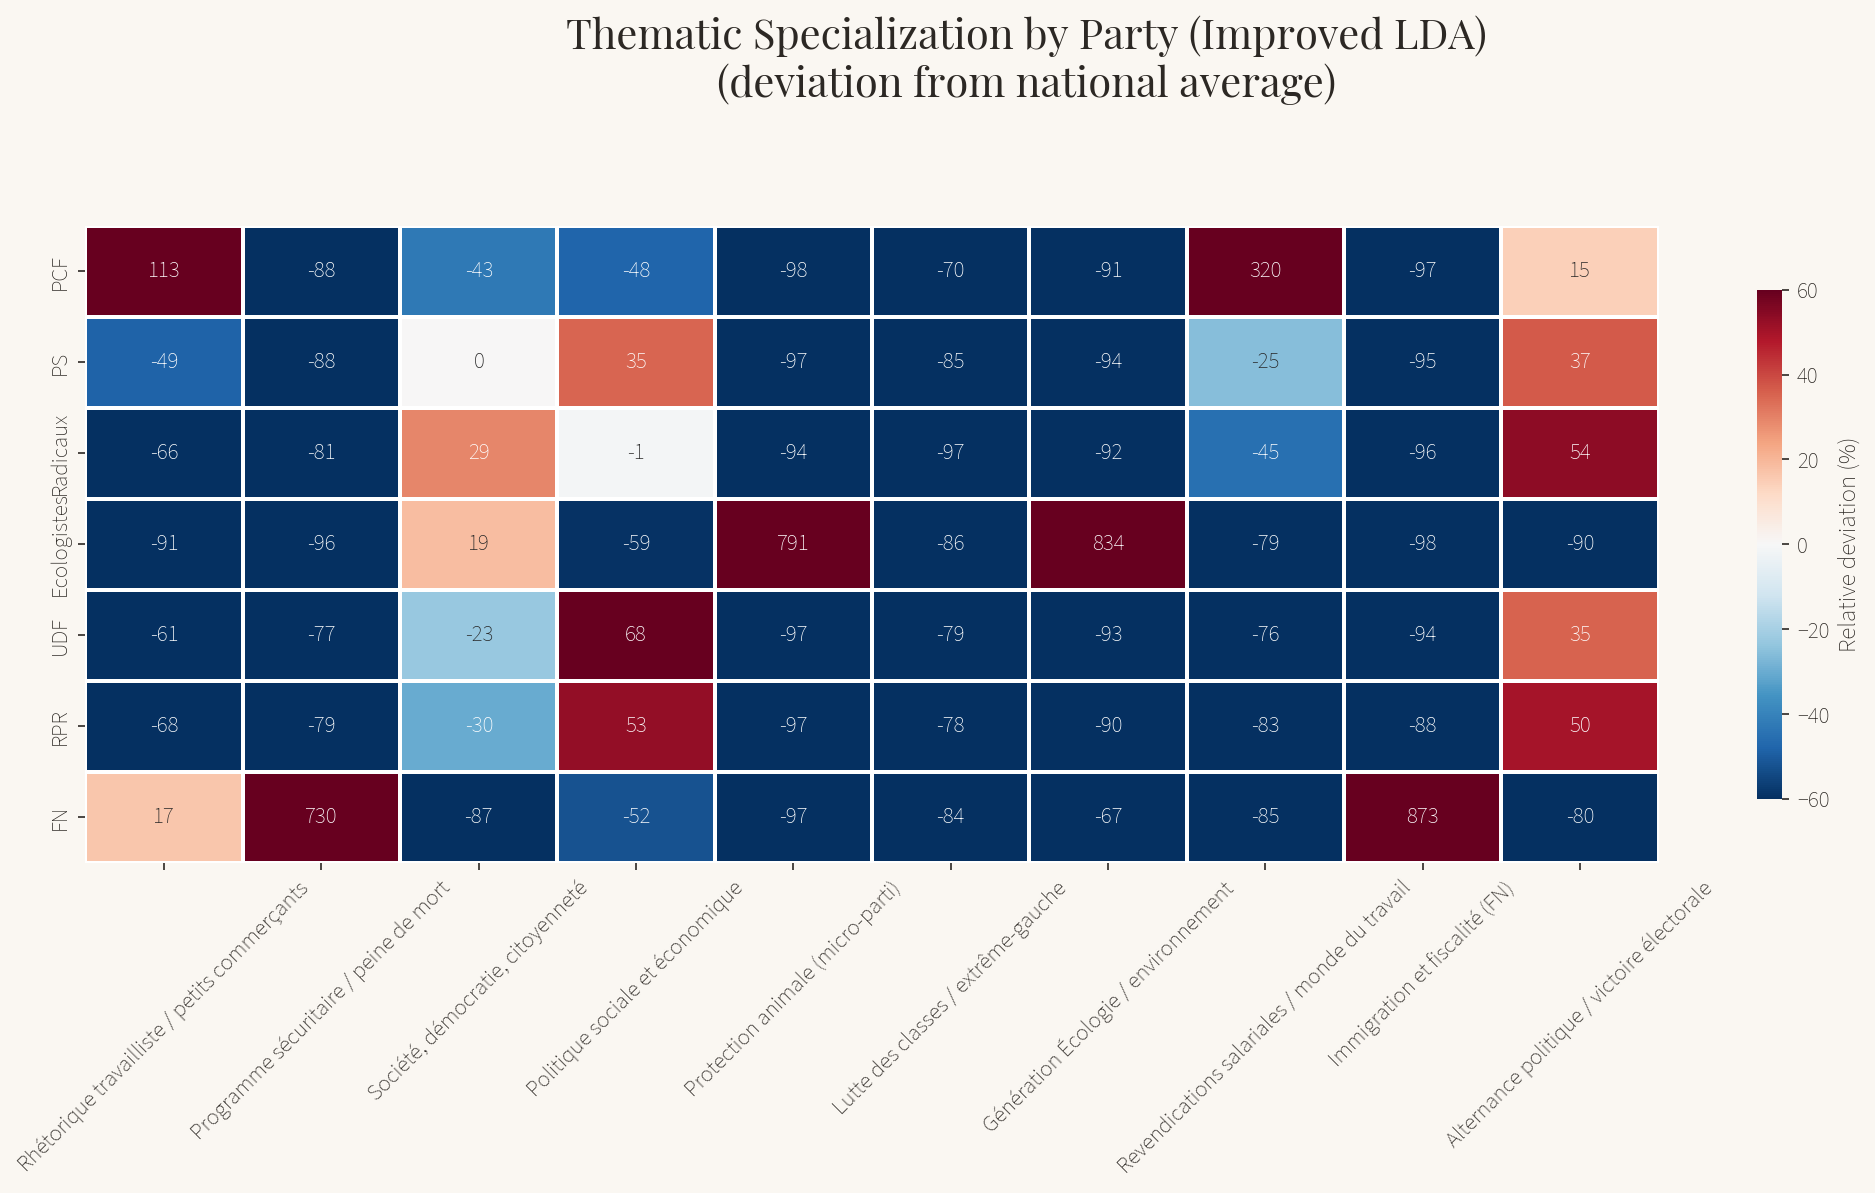

In [22]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Thematic Specialization by Party (Improved LDA)\n(deviation from national average)",
             fontfamily=FONT_TITLE, fontsize=20, fontweight='bold', y=0.99)

national_mean_v2 = df_topic[topic_cols_v2].mean()
spec_v2 = topic_party_v2.copy()
for col_idx, col in enumerate(spec_v2.columns):
    nat_val = national_mean_v2.iloc[col_idx]
    spec_v2[col] = ((spec_v2[col] - nat_val) / nat_val * 100) if nat_val > 0 else 0

sns.heatmap(spec_v2, cmap='RdBu_r', center=0, annot=True, fmt='.0f',
            linewidths=1, linecolor='white', ax=ax, vmin=-60, vmax=60,
            cbar_kws={'label': 'Relative deviation (%)', 'shrink': 0.8})
ax.set_ylabel(''); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/specialisation_v2.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Reading guide:** Red = over-representation (the party discusses this theme *more* than the national average). Blue = under-representation. A score of +40% means the party devotes 40% more weight to this theme than the corpus average. This reveals the "discursive specialization" of each political family.

### 9.4 Temporal evolution

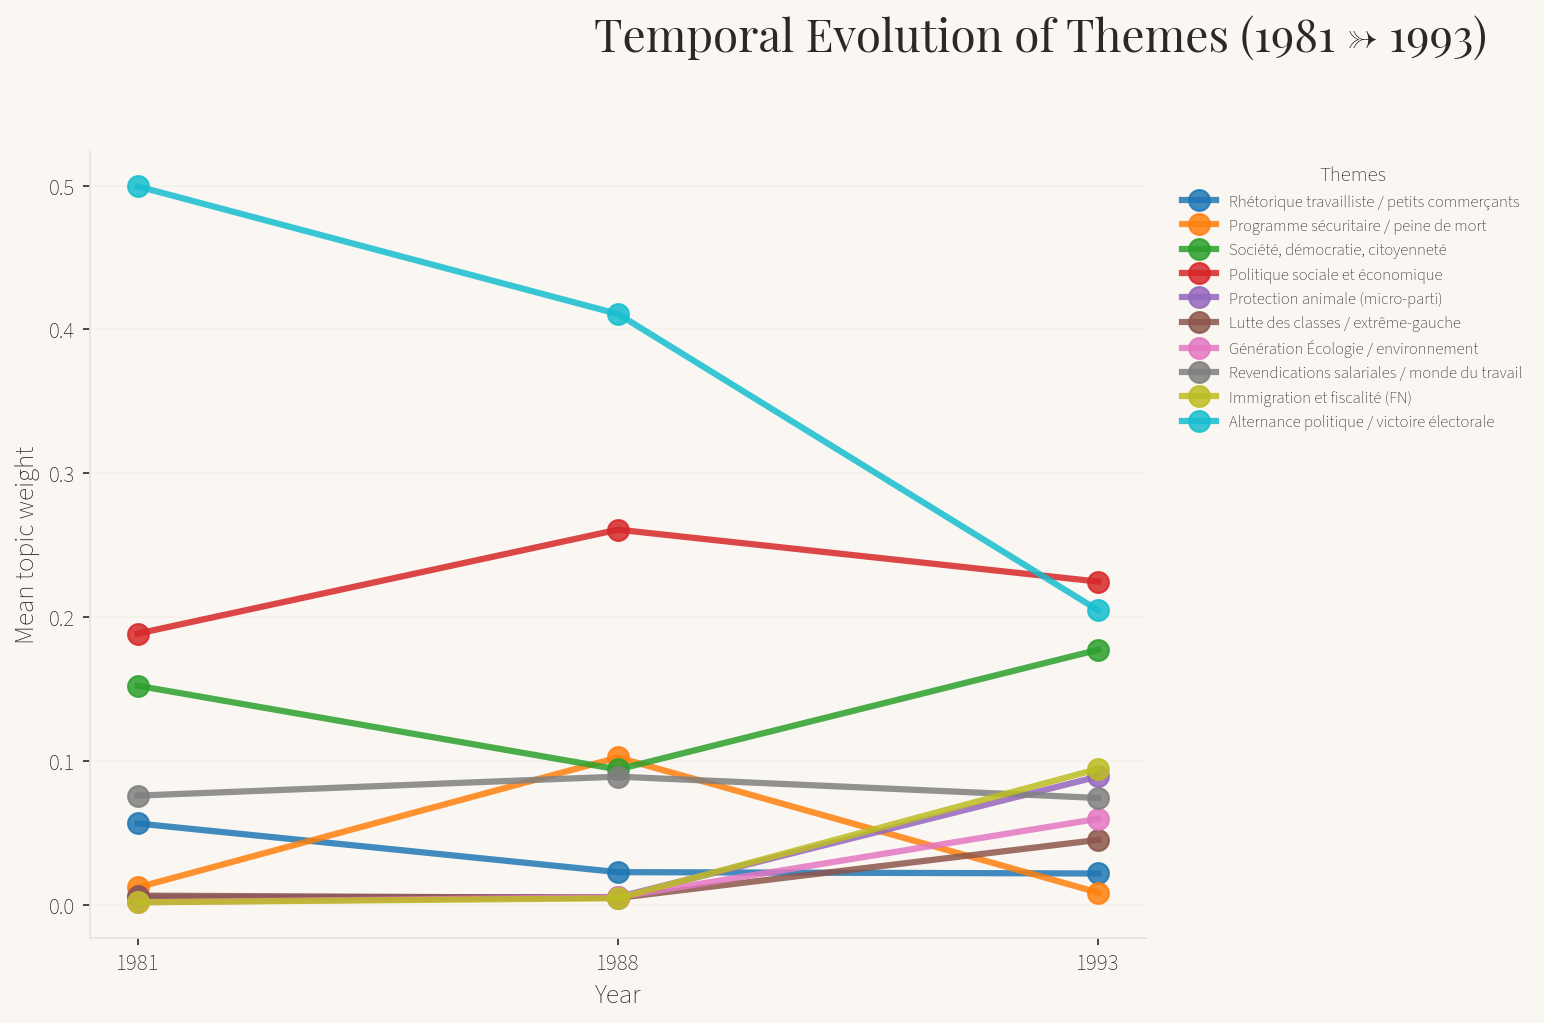

In [23]:
topic_cmap_v2 = plt.cm.tab10

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Temporal Evolution of Themes (1981 → 1993)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

topic_evo_v2 = df_topic.groupby('year')[topic_cols_v2].mean()

for i in range(best_n_topics):
    col = f'topic_v2_{i}'
    label = TOPIC_NAMES_CLEAN.get(i, f"Topic {i}")
    color = topic_cmap_v2(i / best_n_topics)
    ax.plot(topic_evo_v2.index, topic_evo_v2[col],
            marker='o', markersize=10, linewidth=3,
            color=color, label=label, alpha=0.85)

ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Mean topic weight", fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=8,
          title="Themes", title_fontproperties={'weight': 'bold', 'size': 10})

plt.tight_layout(rect=[0, 0, 0.75, 0.93])
plt.savefig("../data/evolution_topics_v2.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Reading guide:** Each curve represents the average weight of a theme across all manifestos of that year. Rising curves indicate themes gaining importance in political discourse. The themes that vary most between 1981 and 1993 are the most analytically interesting.

### 9.5 Semantic map (t-SNE)

Computing t-SNE projection on improved topics...


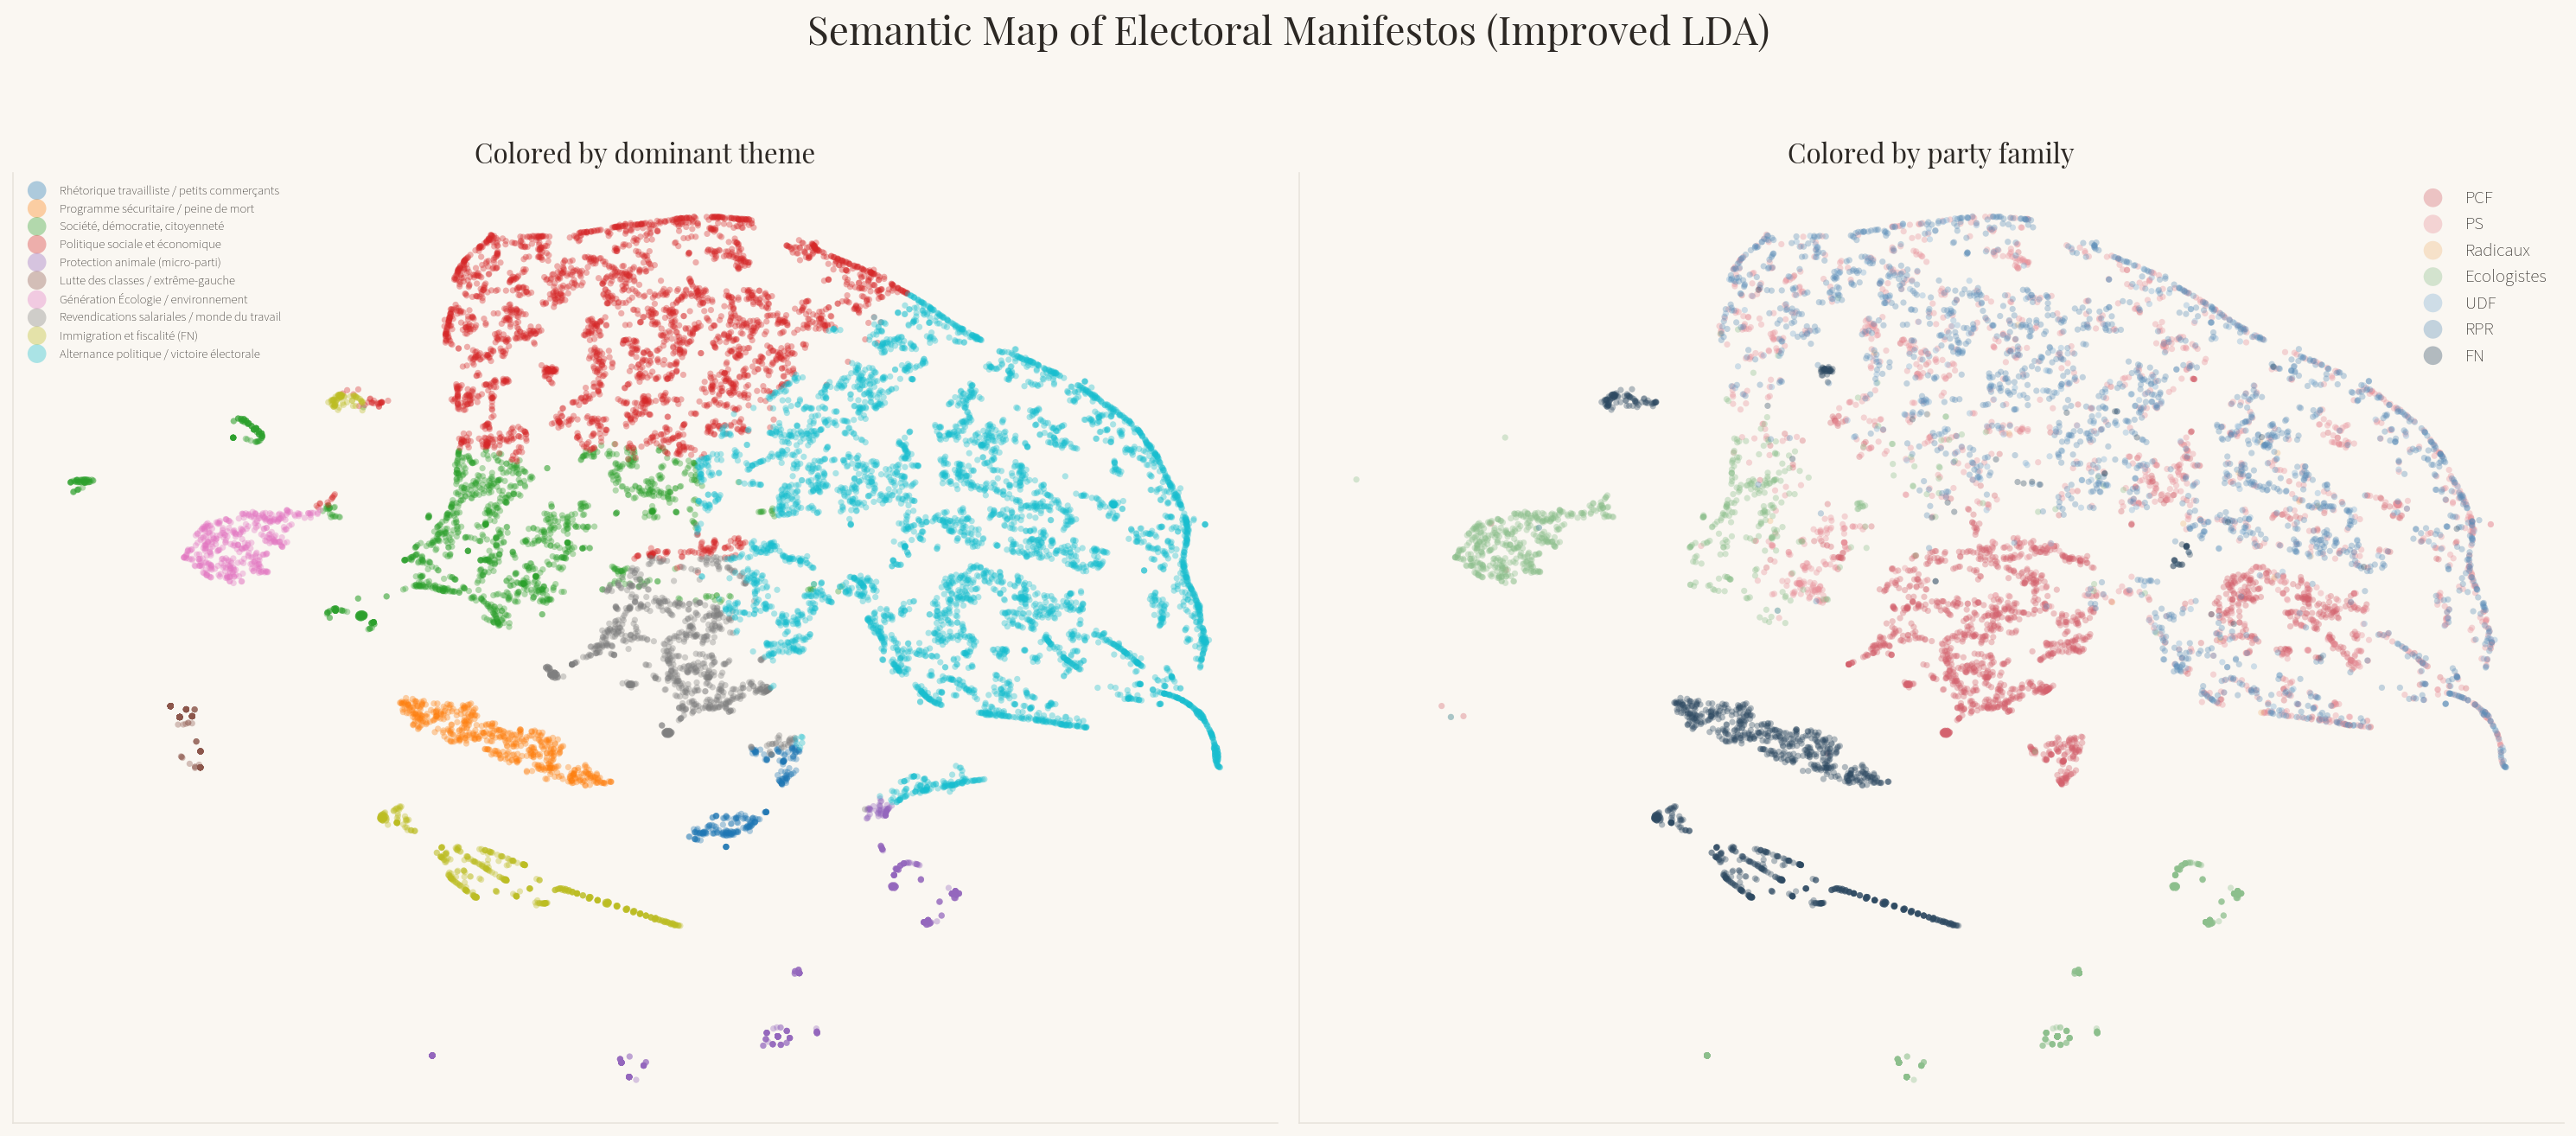

In [24]:
print("Computing t-SNE projection on improved topics...")
tsne_v2 = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=1500)
topics_2d_v2 = tsne_v2.fit_transform(best_topics)

df_topic['tsne_v2_x'] = topics_2d_v2[:, 0]
df_topic['tsne_v2_y'] = topics_2d_v2[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle("Semantic Map of Electoral Manifestos (Improved LDA)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

# Left: by dominant topic
ax = axes[0]
for t in range(best_n_topics):
    mask = df_topic['topic_dominant_v2'] == t
    label = TOPIC_NAMES_CLEAN.get(t, f"Topic {t}")
    color = topic_cmap_v2(t / best_n_topics)
    ax.scatter(df_topic.loc[mask, 'tsne_v2_x'], df_topic.loc[mask, 'tsne_v2_y'],
               c=[color], label=label, alpha=0.35, s=12, edgecolors='none')
ax.legend(frameon=False, fontsize=7, markerscale=3, loc='upper left')
ax.set_title("Colored by dominant theme", fontfamily=FONT_TITLE, fontsize=15)
ax.grid(alpha=0.15); ax.set_xticks([]); ax.set_yticks([])

# Right: by party
ax = axes[1]
for party in main_parties:
    mask = df_topic['parti_famille'] == party
    ax.scatter(df_topic.loc[mask, 'tsne_v2_x'], df_topic.loc[mask, 'tsne_v2_y'],
               c=PARTY_COLORS.get(party, '#A89F96'), label=party,
               alpha=0.35, s=12, edgecolors='none')
ax.legend(frameon=False, fontsize=10, markerscale=3)
ax.set_title("Colored by party family", fontfamily=FONT_TITLE, fontsize=15)
ax.grid(alpha=0.15); ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/tsne_v2_topics_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Reading guide:** Each dot is one manifesto. Nearby documents share similar thematic profiles. The left map shows thematic clusters; the right shows party distribution. Comparing both reveals whether parties cluster by theme (homogeneous discourse) or spread across themes (heterogeneous discourse). A concentrated party = very uniform messaging; a dispersed party = diverse thematic priorities among its candidates.

### 9.6 Semantic map by year

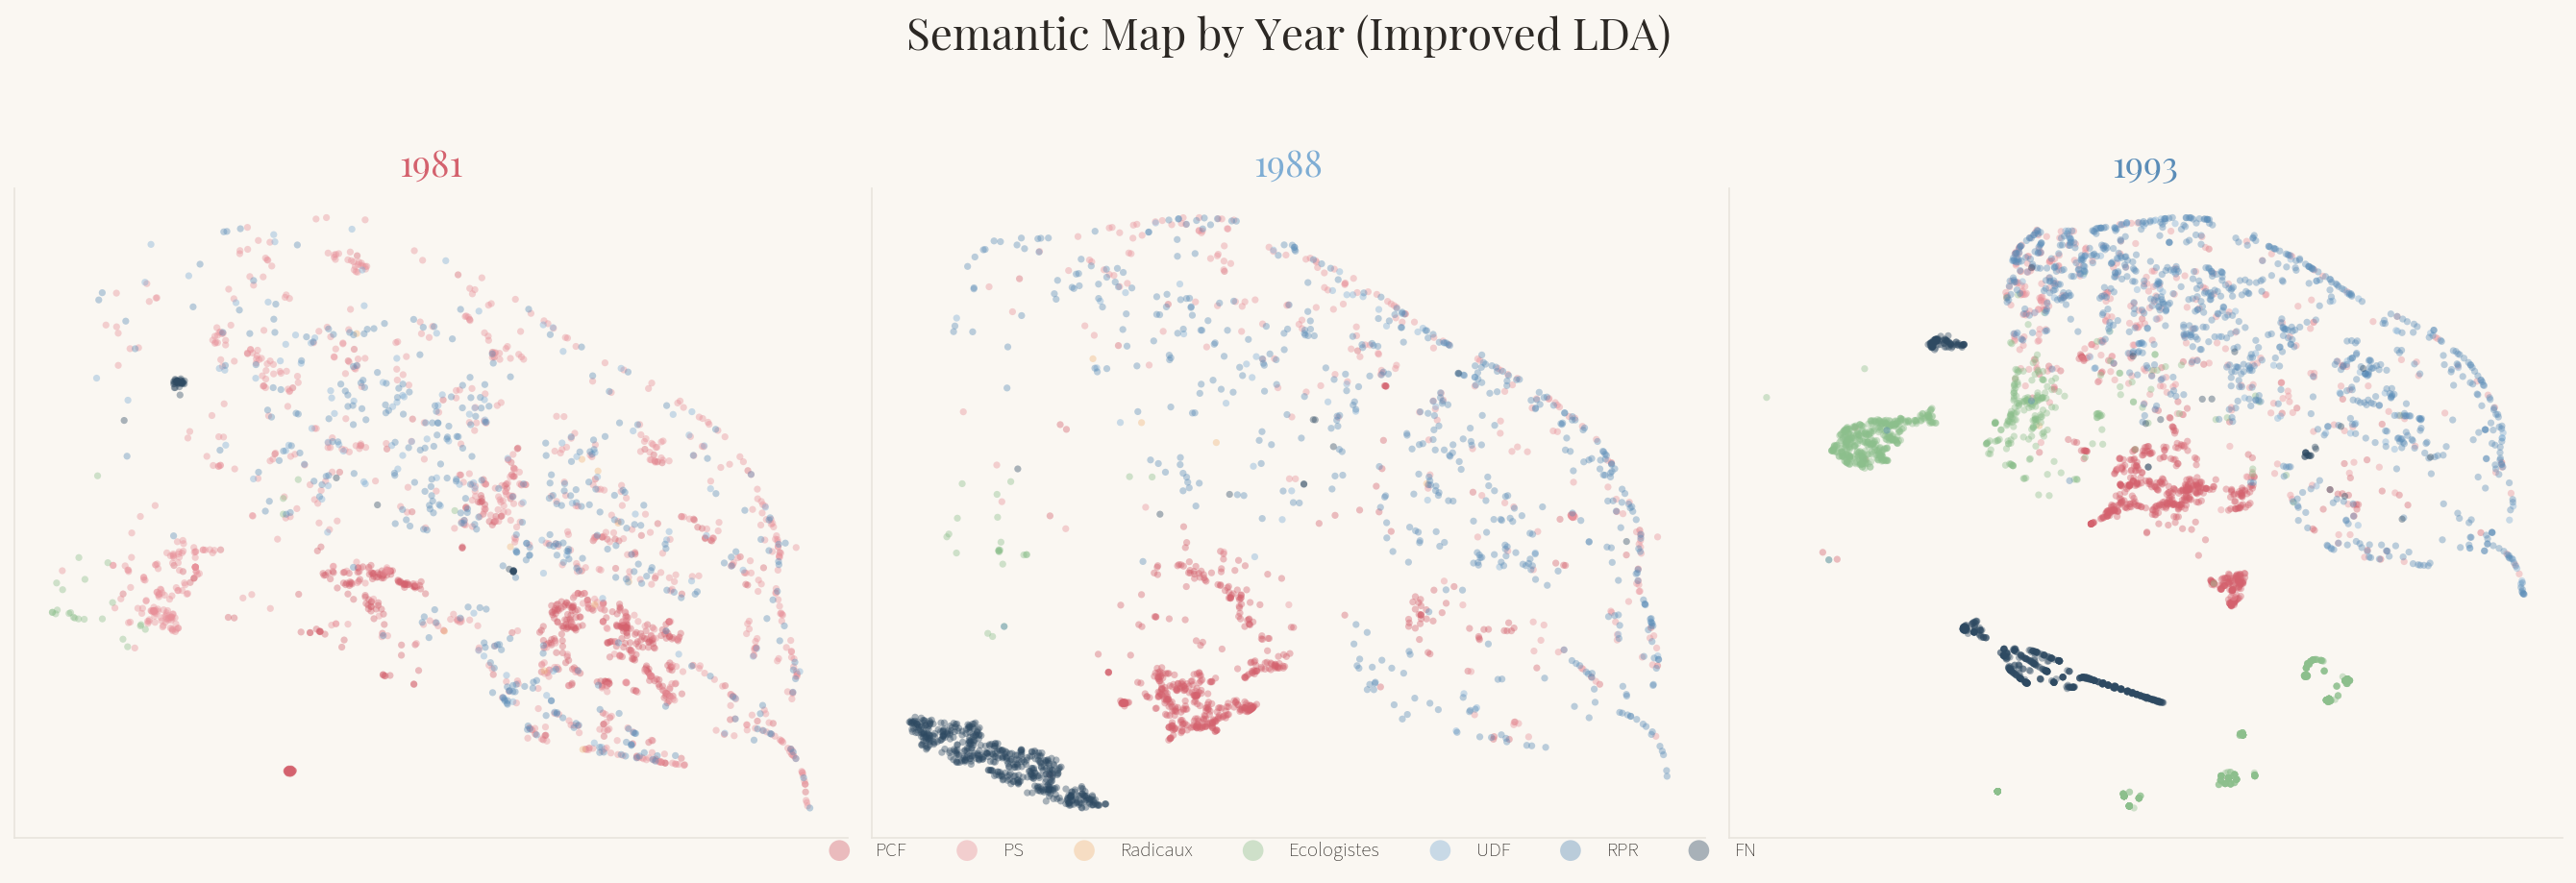

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Semantic Map by Year (Improved LDA)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.98)

for idx, year in enumerate(sorted(df_topic['year'].unique())):
    ax = axes[idx]
    mask = df_topic['year'] == year
    for party in main_parties:
        party_mask = mask & (df_topic['parti_famille'] == party)
        ax.scatter(df_topic.loc[party_mask, 'tsne_v2_x'],
                   df_topic.loc[party_mask, 'tsne_v2_y'],
                   c=PARTY_COLORS.get(party, '#A89F96'),
                   alpha=0.4, s=12, edgecolors='none', label=party)
    ax.set_title(year, fontfamily=FONT_TITLE, fontsize=18, fontweight='bold',
                 color=YEAR_COLORS.get(year, TEXT_COLOR))
    ax.grid(alpha=0.2); ax.set_xticks([]); ax.set_yticks([])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(main_parties),
           frameon=False, fontsize=10, markerscale=3, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/tsne_v2_par_annee.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

**Reading guide:** The same t-SNE projection split by year. Clusters that shift or fragment between 1981 and 1993 indicate evolving political discourse structures.

### 9.7 Most exclusive words per topic

In [26]:
print("=== Most EXCLUSIVE words per topic ===")
print("(words that best distinguish each theme from all others)\n")

for t in range(best_n_topics):
    weights = best_model.components_[t]
    other_weights = np.mean(np.delete(best_model.components_, t, axis=0), axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        exclusivity = np.where(other_weights > 0, weights / other_weights, 0)
    mask_min_weight = weights > np.percentile(weights, 90)
    exclusivity_filtered = exclusivity * mask_min_weight
    top_exclusive = exclusivity_filtered.argsort()[-8:][::-1]
    words = [best_features[i] for i in top_exclusive]
    topic_name = TOPIC_NAMES_CLEAN.get(t, f"Topic {t}")
    print(f"  Topic {t:2d} ({topic_name:45s}) : {', '.join(words)}")

=== Most EXCLUSIVE words per topic ===
(words that best distinguish each theme from all others)

  Topic  0 (Rhétorique travailliste / petits commerçants ) : opposer, pareil, nouveaux immigrés, sapprêtent, tienne, chômage limmigration, joint, damplifier
  Topic  1 (Programme sécuritaire / peine de mort        ) : suppression taxe, maternel, bureaucratique, assassins, priorité demploi, revenu maternel, effectivement, prononce
  Topic  2 (Société, démocratie, citoyenneté             ) : psu, technologies, pouvons accepter, lautogestion, lintolérance, criminalité, cohérente, initiative
  Topic  3 (Politique sociale et économique              ) : cohésion, vœu, préoccuper, loctroi, fatalité déclin, faiblesses, maintien agriculteurs, sy opposer
  Topic  4 (Protection animale (micro-parti)             ) : animaux, nature animaux, nouveaux nature, fonds cevipov, cevipov, écarté, postal, pratiquée
  Topic  5 (Lutte des classes / extrême-gauche           ) : payer, maintenir emplois, bourgeoisi

---

## 10. Save Results

In [27]:
df_topic.to_pickle("../data/df_topics.pkl")

with open("../data/models_topic.pkl", "wb") as f:
    pickle.dump({
        'lda_original': lda,
        'lda_clean': lda_clean,
        'nmf_clean': nmf_clean,
        'count_vectorizer': count_vectorizer,
        'count_vectorizer_clean': count_vec_clean,
        'tfidf_vectorizer_clean': tfidf_vec_clean,
        'topic_names_original': TOPIC_NAMES,
        'topic_names_clean': TOPIC_NAMES_CLEAN,
        'N_TOPICS_ORIGINAL': N_TOPICS,
        'N_TOPICS_CLEAN': N_TOPICS_CLEAN,
    }, f)

print(f"✓ DataFrame saved: {len(df_topic):,} rows with {N_TOPICS_CLEAN} improved topics")
print(f"✓ Models saved to ../data/models_topic.pkl")

✓ DataFrame saved: 12,419 rows with 10 improved topics
✓ Models saved to ../data/models_topic.pkl


---

## 11. Summary & Next Steps

### What we achieved

| Step | Result |
|------|--------|
| Baseline LDA (12 topics, full vocab) | Captures partisan identities, not themes |
| Language filtering | 325 German-language documents removed |
| Optimal k selection | k=10 selected via perplexity elbow |
| Improved LDA (10 topics, clean vocab) | Genuine policy themes extracted |
| NMF comparison | Alternative decomposition for robustness |
| Visualizations | Heatmaps, specialization, t-SNE maps |

### Key findings so far

- Removing partisan vocabulary fundamentally changes what the model captures
- The improved model reveals cross-partisan themes (economy, immigration, environment)
- Some topics remain party-specific even after vocabulary cleaning (e.g., "Protection animale" for Nouveaux Écologistes)

### What comes next

In **Notebook 04 (Cross-Analysis)**, we will:
- Cross-reference topics with metadata (profession, age, gender) to test whether socio-demographic background predicts thematic focus
- Analyze thematic sentiment: *how* parties discuss the same themes differently
- Compare manifesto themes with real economic indicators (INSEE data) by department